<a href="https://colab.research.google.com/github/PradipBanik/Build_2026/blob/main/Andrew_Karaoathy_summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# nodes

In [ ]:
import numpy as np

class nodes:
  def __init__(self, data, prev=(), op='', label=''):
    self._data = data
    self._prev = set(prev)
    self._op = op
    self._label = label
    self._grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    return f"{self._data}"

  def __add__(self, other):
    other = other if isinstance(other, nodes) else nodes(other, label=f"{other}")
    add_out = nodes(self._data + other._data, (self, other), '+')
    def _backward():
      self._grad += 1.0 * add_out._grad
      other._grad += 1.0 * add_out._grad
    add_out._backward = _backward
    return add_out

  def __radd__(self, other):
    return self + other

  def __sub__(self, other):
    other = other if isinstance(other, nodes) else nodes(other, label=f"{other}")
    out =  nodes(self._data-other._data, (self, other), '-')
    def _backward():
      self._grad += 1.0 * out._grad
      other._grad += -1.0 * out._grad
    out._backward = _backward
    return out

  def __rsub__(self,other):
      return nodes(other, label=f"{other}")-self

  def __neg__(self):
      return self * -1

  def __mul__(self, other):
    other = other if isinstance(other, nodes) else nodes(other, label=f"{other}")
    out = nodes(self._data * other._data, (self, other), '*')
    def _backward():
      self._grad += other._data * out._grad
      other._grad += self._data * out._grad
    out._backward = _backward
    return out

  def __rmul__(self, other):
    return self * other

  def __pow__(self, other):
    assert isinstance(other, (int,float)), "only float and int are supported"
    out = nodes(self._data ** other, (self,), f"**{other}")
    def _backward():
      self._grad += other * (self._data ** (other  - 1)) * out._grad
    out._backward = _backward
    return out

  def __truediv__(self, other):
    return self * (other**-1)

  def __rtruediv__(self, other):
    return nodes(other, label=f"{other}") / self

  def exp(self):
    out = nodes(np.exp(self._data), (self,), 'e')
    def _backward():
      self._grad += out._data * out._grad
    out._backward = _backward
    return out

  def log(self):
    out = nodes(np.log(self._data), (self,), 'log')
    def _backward():
      self._grad += (1.0 / self._data) * out._grad
    out._backward = _backward
    return out

  def tanh(self):
    e2x = (self * 2).exp()
    e2x._op = 'e^2x'
    out = (e2x - 1) *( (e2x + 1)**-1)
    out._op = 'tanh'
    return out

  def _sin(self):
    v = self._data
    out_sin = nodes(np.sin(v), (self,), 'sin')
    def _backward():
      self._grad += np.cos(v) * out_sin._grad
    out_sin._backward = _backward
    return out_sin

  def _cos(self):
    v = self._data
    out_cos = nodes(np.cos(v), (self,), 'cos')
    def _backward():
      self._grad += -np.sin(v) * out_cos._grad
    out_cos._backward = _backward
    return out_cos

  def backward(self):
    topo=[]
    visited=[]
    def build_topo(v):
      if v not in visited:
        visited.append(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self._grad = 1.0
    for node in reversed(topo):
      node._backward()

  def _zero_grad(self):
    self._grad = 0.0

### Mathematical Breakdown of `(self * 2).exp()`

1.  **`self * 2`**: This triggers `__mul__`. It creates a new node where the data is $x \times 2$ and the `_op` is `*`.
2.  **`.exp()`**: This triggers your `exp` method on that new node. It takes the data ($2x$) and returns `nodes(np.exp(data))`, which is $e^{2x}$.

This is why your `tanh` implementation works:
$$\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}$$

In [ ]:
# @title
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # label_str = f"{n.label} | data {n.wt_data:.4f} | grad {n.grad:.4f}"

    # Extract scalar values from potential node objects to prevent formatting errorsz
    data_val = n._data._data if hasattr(n._data, '_data') else n._data
    grad_val = n._grad._data if hasattr(n._grad, '_data') else n._grad

    label_str = f"{n._label} | data {float(data_val):.4f} | grad {float(grad_val):.4f}"

    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

In [ ]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))

    # Safety check: extract raw scalar if the attribute is another node
    # This prevents 'TypeError: unsupported format string passed to nodes.__format__'
    data_val = n._data._data if hasattr(n._data, '_data') else n._data
    grad_val = n._grad._data if hasattr(n._grad, '_data') else n._grad

    # Explicitly cast to float to support formatting codes like :.4f
    label_str = f"{n._label} | data {float(data_val):.4f} | grad {float(grad_val):.4e}"

    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

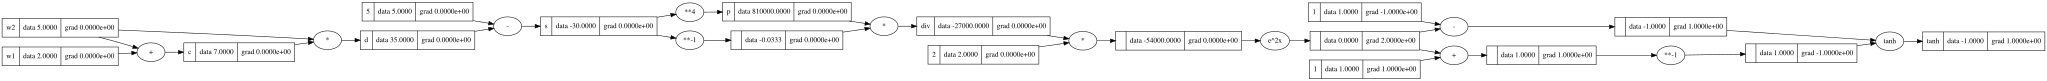

In [ ]:
draw_dot(tanh)

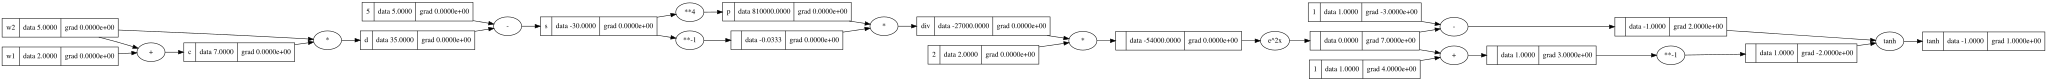

In [ ]:
tanh.backward()
draw_dot(tanh)


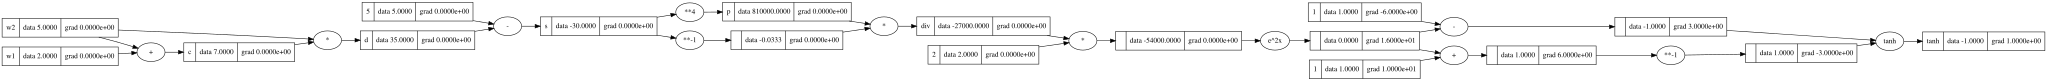

In [ ]:
tanh.backward()
draw_dot(tanh)

y data: 0.0997
x1 gradient: 0.1980


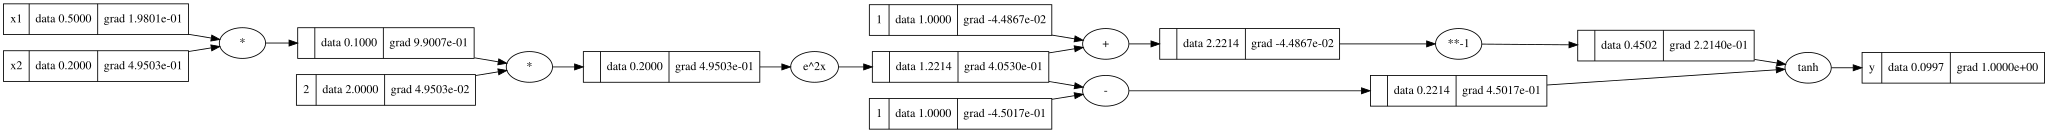

In [ ]:
# Testing with smaller values to see non-zero gradients
x1 = nodes(0.5, label='x1')
x2 = nodes(0.2, label='x2')
y = (x1 * x2).tanh(); y._label = 'y'
y.backward()

print(f"y data: {y._data:.4f}")
print(f"x1 gradient: {x1._grad:.4f}")
draw_dot(y)

y data: 0.0997
x1 gradient: 0.1980


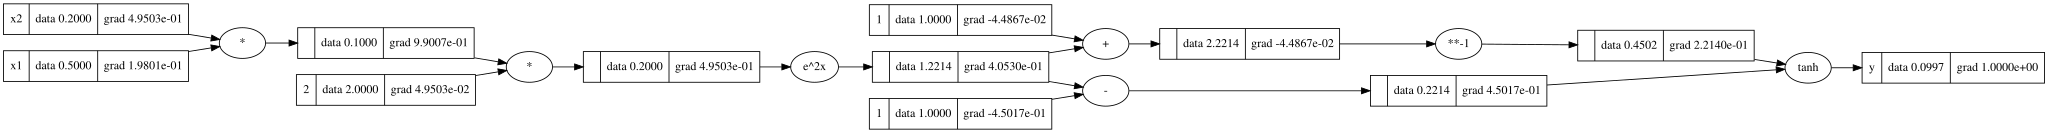

In [ ]:
# Testing with smaller values to see non-zero gradients
x1 = nodes(0.5, label='x1')
x2 = nodes(0.2, label='x2')
y = (x1 * x2).tanh(); y._label = 'y'
y.backward()

print(f"y data: {y._data:.4f}")
print(f"x1 gradient: {x1._grad:.4f}")
draw_dot(y)

In [ ]:
a = nodes(2, label='a')
b = nodes(3, label='b')
c = nodes(4, label='c')
f = -a**3 + (3*b)._sin() - 1.0/c + b**2.5 - a**0.5
# df/da = -3*(a^2)- 0.5*(a^-0.5)
f.backward()
print(f._data)
# print(f(2, 3, 4))

6.336362190988558


In [ ]:
import math

# Manual calculation using values a=2, b=3, c=4
a_val, b_val, c_val = 2.0, 3.0, 4.0

# Derivatives
df_da = -3 * (a_val**2) - 0.5 * (a_val**-0.5)
df_db = 3 * math.cos(3 * b_val) + 2.5 * (b_val**1.5)
df_dc = 1.0 / (c_val**2)

print("--- Manual vs Autograd ---")
print(f"df/da: Manual = {df_da:.6f} | Autograd = {a._grad:.6f}")
print(f"df/db: Manual = {df_db:.6f} | Autograd = {b._grad:.6f}")
print(f"df/dc: Manual = {df_dc:.6f} | Autograd = {c._grad:.6f}")

# Check if results match closely
assert math.isclose(df_da, a._grad, rel_tol=1e-9)
assert math.isclose(df_db, b._grad, rel_tol=1e-9)
assert math.isclose(df_dc, c._grad, rel_tol=1e-9)
print("\nVerification successful: All gradients match!")

--- Manual vs Autograd ---
df/da: Manual = -12.353553 | Autograd = -12.353553
df/db: Manual = 10.256990 | Autograd = 10.256990
df/dc: Manual = 0.062500 | Autograd = 0.062500

Verification successful: All gradients match!


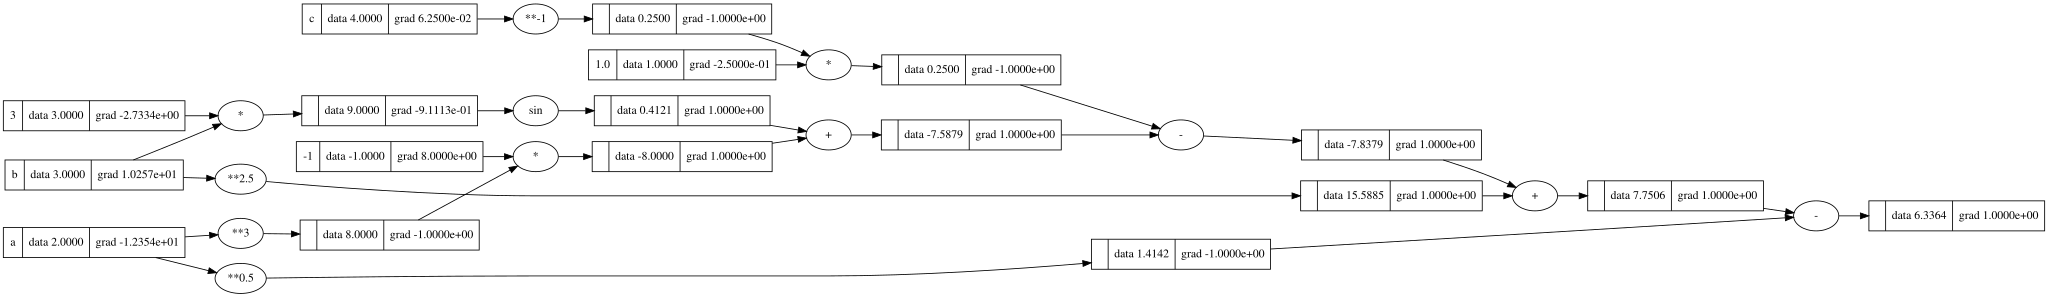

In [ ]:
draw_dot(f)

#Neural layer

neuron

In [ ]:
class neuron:
  def __init__(self, n_wt):
    self.w = [nodes(np.random.uniform(-1,1)) for _ in range(n_wt)]
    self.b = nodes(np.random.uniform(-1,1))

  def __call__(self, _inp):
    act = sum((wi*xi for wi, xi in zip(self.w, _inp)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

layer

In [ ]:
class layer:
  def __init__(self, n_wt, n_neu):
    self.neurons = [neuron(n_wt) for _ in range(n_neu)]

  def __call__(self, _inp):
    out = [n(_inp) for n in self.neurons]
    return out[0] if len(out) == 1 else out

  def parameters(self):
    return [p for n in self.neurons for p in n.parameters()]



In [ ]:
# @title
_in = [1,2,1,2,1]
n_wt = 5
n_neu = 3
_layer = layer(n_wt, n_neu)
out_nodes = _layer(_in) # Compute the output of the layer

# Reset gradients across the whole layer
for p in _layer.parameters():
  p._zero_grad()

out_nodes[0].backward() # Backpropagate from the first output node
draw_dot(out_nodes[0]) # Draw the graph for the first output node

multi layer

In [ ]:
class mlayer:
  def __init__(self, n_wt, n_neu, n_layer):
    # Comprehension: sets first layer input to n_wt, and last layer output to 1
    self.layers = [layer(n_wt if i == 0 else n_neu, 1 if i == n_layer - 1 else n_neu) for i in range(n_layer)]

  def __call__(self, x):
    for l in self.layers:
      x = l(x)
    return x

  def parameters(self):
    return [p for l in self.layers for p in l.parameters()]

In [ ]:
# @title

_in = [1,2,1]
n_wt = 3
n_neu = 3
n_layer = 3

# @title
# Initialize the MLP using the defined variables
# Note: parameters are (n_wt, n_neu, n_layer)
mlp = mlayer(n_wt, n_neu, n_layer)



In [ ]:
# @title

# Run a forward pass
mlp_out = mlp(_in)

print(f"Number of layers: {len(mlp.layers)}")
print(f"Number of parameters: {len(mlp.parameters())}")

# mlp_out = np.array(mlp_out, dtype=object)
print(f"Output nodes: {mlp_out}")

Number of layers: 3
Number of parameters: 28
Output nodes: 0.4119669067625494


In [ ]:
# @title
t_loss =  (1 - mlp_out)**2
# t_loss = sum(ind_loss)
# print(f"Output:{mi_mlp}")
# print(f"required output:{_tar}")
# print(f"loss:{ind_loss}")
print(f"loss:{t_loss}")



loss:0.34578291874240435


In [ ]:
# @title
# Zero the gradients for all parameters in the model
[p._zero_grad() for p in mlp.parameters()]
[p._grad for p in mlp.parameters()]


[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [ ]:
# @title
t_loss.backward()
[p._grad for p in mlp.parameters()]

[np.float64(-0.015966255170981637),
 np.float64(-0.031932510341963274),
 np.float64(-0.015966255170981637),
 np.float64(-0.015966255170981637),
 np.float64(0.024507135218696137),
 np.float64(0.049014270437392274),
 np.float64(0.024507135218696137),
 np.float64(0.024507135218696137),
 np.float64(0.18547096938042407),
 np.float64(0.37094193876084813),
 np.float64(0.18547096938042407),
 np.float64(0.18547096938042407),
 np.float64(0.13511100822765867),
 np.float64(-0.13112026638535856),
 np.float64(0.10421386830546552),
 np.float64(-0.1417774354461),
 np.float64(-0.6284423437344641),
 np.float64(0.6098801911052095),
 np.float64(-0.4847303599212912),
 np.float64(0.6594499218766784),
 np.float64(0.391433490199323),
 np.float64(-0.3798718119296746),
 np.float64(0.3019206113039001),
 np.float64(-0.4107469636720202),
 np.float64(-0.8377965556920497),
 np.float64(-0.5512157162440777),
 np.float64(-0.7345817970574958),
 np.float64(-0.9764680763760771)]

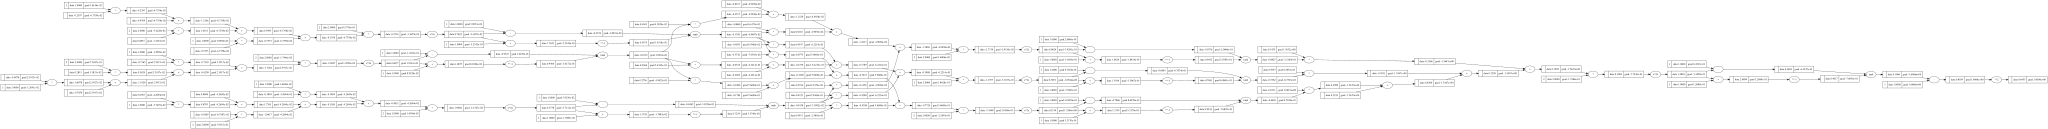

In [ ]:
# @title
draw_dot(t_loss)


In [ ]:
# @title
# Comprehension style update for all parameters
learning_rate = 0.01

# This performs the SGD update: p = p - lr * grad
# We use 'setattr' because assignment (p._data = ...) is not allowed inside a list comprehension
[setattr(p, '_data', p._data - learning_rate * p._grad) for p in mlp.parameters()]

print(f"Updated {len(mlp.parameters())} parameters.")
print("First 5 updated values:", [p._data for p in mlp.parameters()][:5])

Updated 28 parameters.
First 5 updated values: [np.float64(-0.48801715035231524), np.float64(0.2809497561978202), np.float64(-0.7167548946973921), np.float64(-0.7052926870351781), np.float64(-0.23902945290904198)]


putting the code in 1 section

In [ ]:

for _ in range(100):
  # Run a forward pass
  mlp_out = mlp(_in)

  print(f"Number of layers: {len(mlp.layers)}")
  print(f"Number of parameters: {len(mlp.parameters())}")

  # mlp_out = np.array(mlp_out, dtype=object)
  print(f"Output nodes: {mlp_out}")

  # Zero the gradients for all parameters in the model
  [p._zero_grad() for p in mlp.parameters()]
  # [p._grad for p in mlp.parameters()]

  # @title
  t_out =1
  t_loss =  ( t_out - mlp_out)**2
  # t_loss = sum(ind_loss)
  # print(f"Output:{mi_mlp}")
  # print(f"required output:{_tar}")
  # print(f"loss:{ind_loss}")
  print(f"loss:{t_loss}")



  t_loss.backward()
  # [p._grad for p in mlp.parameters()]

  # Comprehension style update for all parameters
  learning_rate = 0.01

  # This performs the SGD update: p = p - lr * grad
  # We use 'setattr' because assignment (p._data = ...) is not allowed inside a list comprehension
  [setattr(p, '_data', p._data - learning_rate * p._grad) for p in mlp.parameters()]

  print(f"Updated {len(mlp.parameters())} parameters.")
  print("First 5 updated values:", [p._data for p in mlp.parameters()][:5])


Number of layers: 3
Number of parameters: 28
Output nodes: -0.8289171965233766
loss:3.3449381117389274
Updated 28 parameters.
First 5 updated values: [np.float64(0.8156345823183043), np.float64(0.18732684174594577), np.float64(0.12434016919530003), np.float64(0.49476187220966483), np.float64(0.14831507210259737)]
Number of layers: 3
Number of parameters: 28
Output nodes: -0.8084001823417402
loss:3.2703112194936392
Updated 28 parameters.
First 5 updated values: [np.float64(0.8163916388579243), np.float64(0.1888409548251857), np.float64(0.12509722573492), np.float64(0.4955189287492848), np.float64(0.14429983205740735)]
Number of layers: 3
Number of parameters: 28
Output nodes: -0.7838309343394405
loss:3.1820528023063215
Updated 28 parameters.
First 5 updated values: [np.float64(0.8172062251717511), np.float64(0.19047012745283926), np.float64(0.12591181204874677), np.float64(0.4963335150631116), np.float64(0.13995531968545236)]
Number of layers: 3
Number of parameters: 28
Output nodes: -0

In [ ]:
class SimpleNeuron:
    def __init__(self, name):
        # This runs once at creation
        self.name = name
        print(f"Neuron {self.name} initialized!")

    def __call__(self, x):
        # This runs every time you use the object as a function
        print(f"Neuron {self.name} is processing input: {x}")
        return x * 2

# 1. Initialization (__init__ is called)
my_neuron = SimpleNeuron("Alpha")

# 2. Execution (__call__ is called)
result = my_neuron(10)
print(f"Result: {result}")

Neuron Alpha initialized!
Neuron Alpha is processing input: 10
Result: 20


In [ ]:
print(mlp.parameters())

[0.34091683666481404, -0.4689950378050164, 0.2601600266337915, -0.4248205662572147, 0.9766078835577089, -0.28367628988671373, 0.46538661546873916, -0.010164473466666485, 0.8058572097226542, 0.32620801362631796, -0.0740388156273805, -0.7384363234914126, -0.3620838977668516, -0.1713057961027846, 0.7672563178362167, -1.0729641259848377, 0.6405233623680083, -0.6635351807487156, -1.0371843377436332, -0.13735128430091428, -0.3517414221156244, -0.732144630288583, -0.16917103481799659, -0.6786212373646455, -0.2705374220567604, -0.8068103871685398, -0.4001677052085438, 0.25963225201253154]


Another case implementtion with multi input

In [ ]:
# @title
_in = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
]
_tar = [0.7, 1, 0.9]

# Re-initialize the model here to get fresh random weights each time you run this cell
mlp = mlayer(n_wt, n_neu, n_layer)

mi_mlp = [mlp(_input) for _input in _in]
print(mi_mlp)

[-0.5733874386580029, -0.9160770887956075, -0.0009481812646083443]


loss

In [ ]:
# @title
ind_loss =  [(_rout - _out)**2 for _out, _rout in zip(mi_mlp, _tar)]
t_loss = sum(ind_loss)
print(f"Output:{mi_mlp}")
print(f"required output:{_tar}")
print(f"loss:{ind_loss}")
print(f"loss:{t_loss}")

Output:[0.5215892211548634, 0.6248801349190575, 0.5571556858779994]
required output:[8, -10, 0.9]
loss:[55.92662777714712, 112.88807788139762, 0.11754222372578507]
loss:168.93224788227053


gradient

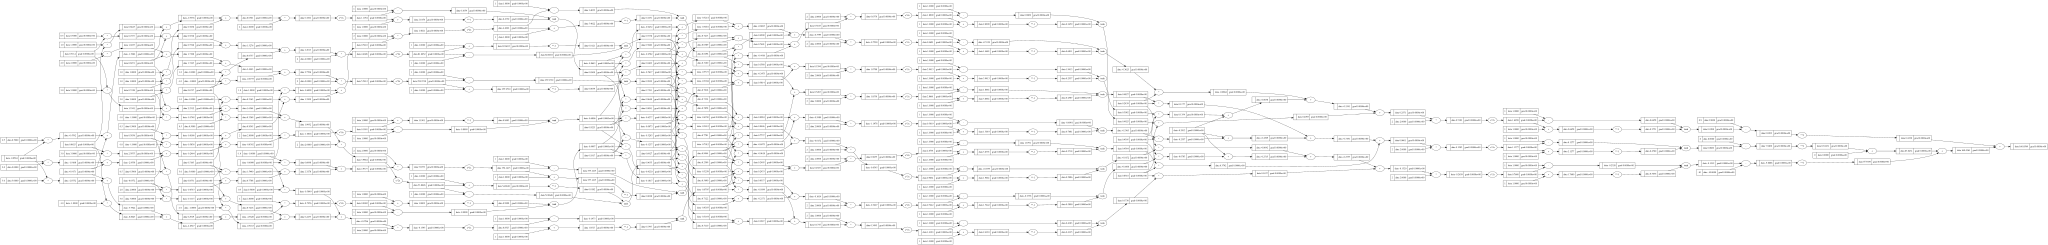

In [ ]:
draw_dot(t_loss)


In [ ]:
# @title
# Zero the gradients for all parameters in the model
[p._zero_grad() for p in mlp.parameters()]

t_loss.backward()
# draw_dot(t_loss)

all in A go

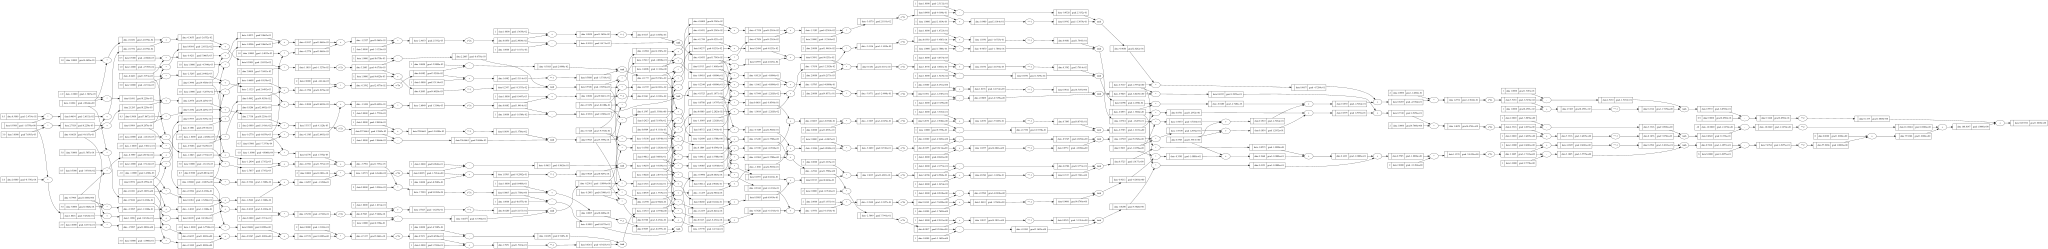

In [ ]:
# @title
# ALWAYS follow this order for a clean state:

# 1. Forward Pass: Creates NEW nodes for the graph (fresh _grad = 0.0 for intermediates)
mi_mlp = [mlp(_input) for _input in _in]
ind_loss = [(_rout - _out)**2 for _out, _rout in zip(mi_mlp, _tar)]
t_loss = sum(ind_loss)

# 2. Zero Gradients: Clear the persistent weight/bias nodes
for p in mlp.parameters():
    p._zero_grad()

# 3. Backward Pass: Populate gradients in the fresh graph
t_loss.backward()

# Now the visualization will show exactly the gradients for THIS single pass
draw_dot(t_loss)


In [ ]:
learning_rate = 0.8 # Further increased to combat tanh saturation
for epoch in range(5001):
  # 1. Forward pass
  mi_mlp = [mlp(_input) for _input in _in]
  ind_loss = [(_rout - _out)**2 for _out, _rout in zip(mi_mlp, _tar)]
  t_loss = sum(ind_loss)

  # 2. Zero gradients
  [p._zero_grad() for p in mlp.parameters()]

  # 3. Backward pass
  t_loss.backward()

  # 4. Update parameters
  for p in mlp.parameters():
    p._data -= learning_rate * p._grad

  if epoch % 500 == 0:
    print(f"Epoch {epoch} | Loss: {t_loss._data:.6f} | Outputs: {[float(o._data) for o in mi_mlp]}")

print(f"\nFinal Loss: {t_loss._data:.6f}")
print(f"Final Outputs: {[float(o._data) for o in mi_mlp]}")
print(f"Targets: {_tar}")

Epoch 0 | Loss: 0.000066 | Outputs: [0.6943462298393458, 0.994468602376848, 0.8981514065277775]
Epoch 500 | Loss: 0.000119 | Outputs: [0.6913059370081178, 0.9943699970821674, 0.8965176000305777]
Epoch 1000 | Loss: 0.000053 | Outputs: [0.6947607700647138, 0.9953809178569222, 0.8978359418011875]
Epoch 1500 | Loss: 0.000043 | Outputs: [0.6952598777759613, 0.9959889073471031, 0.8980012210827281]
Epoch 2000 | Loss: 0.000036 | Outputs: [0.6955615876591179, 0.9964094903792318, 0.898099322075631]
Epoch 2500 | Loss: 0.000028 | Outputs: [0.6961814636038313, 0.9967238354651741, 0.8983440980971661]
Epoch 3000 | Loss: 0.000022 | Outputs: [0.696696802123837, 0.9969677314940468, 0.8985524207005308]
Epoch 3500 | Loss: 0.000021 | Outputs: [0.6967314473958128, 0.9971631628475912, 0.8985551726945077]
Epoch 4000 | Loss: 0.000019 | Outputs: [0.696842009688055, 0.9973266883602839, 0.898593518889568]
Epoch 4500 | Loss: 0.000016 | Outputs: [0.6971059022475891, 0.9974652374900254, 0.8987022219532615]
Epoch 500

# softmax

In [ ]:
# @title
def softmax(logits):
    # logits is a list of nodes objects
    counts = [logit.exp() for logit in logits]
    denominator = sum(counts)
    out = [c / denominator for c in counts]
    return out

# Apply softmax to your MLP output
probs = softmax(mlp_out)
for i, p in enumerate(probs):
    p._label = f"prob_{i}"
    print(f"Probability {i}: {p._data:.4f}")

Probability 0: 0.4088
Probability 1: 0.1368
Probability 2: 0.4544


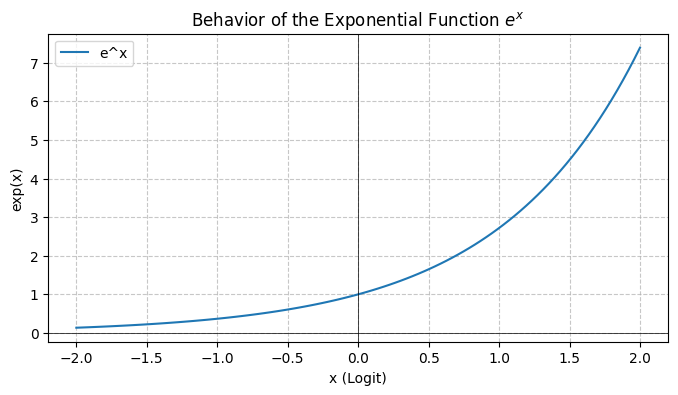

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 100)
y = np.exp(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='e^x')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Behavior of the Exponential Function $e^x$")
plt.xlabel("x (Logit)")
plt.ylabel("exp(x)")
plt.legend()
plt.show()

In [ ]:
# @title
# Define a target (e.g., class 0)
target = [1.0, 0.0, 0.0]

# Recalculate probs to ensure nodes have the new 'log' method
probs = softmax(mlp_out)

# Cross-Entropy Loss: -sum(target_i * log(prob_i))
loss = sum([-(t * p.log()) for p, t in zip(probs, target)])
loss._label = 'cross_entropy_loss'

print(f"Cross-Entropy Loss: {loss._data:.4f}")

# Reset gradients before backprop
for p in mlp.parameters():
    p._zero_grad()

loss.backward()
print("Backpropagation complete with Cross-Entropy.")

Cross-Entropy Loss: 0.8946
Backpropagation complete with Cross-Entropy.


In [ ]:
# @title
learning_rate = 0.01

# Update each parameter using gradient descent
for p in mlp.parameters():
    p._data -= learning_rate * p._grad

# Run a second forward pass to see if the loss decreased
mlp_out_new = mlp(_in)
probs_new = softmax(mlp_out_new)
loss_new = sum([-(t * p.log()) for p, t in zip(probs_new, target)])

print(f"Initial Loss: {loss._data:.4f}")
print(f"Loss after 1 step of SGD: {loss_new._data:.4f}")
print(f"Loss reduction: {loss._data - loss_new._data:.4f}")

Initial Loss: 0.8946
Loss after 1 step of SGD: 0.8871
Loss reduction: 0.0076


In [ ]:
# @title
epochs = 50
learning_rate = 0.1 # Increasing learning rate for faster visible convergence

print(f"Starting training loop for {epochs} epochs...")

for i in range(epochs):
    # 1. Forward pass
    out = mlp(_in)
    probs = softmax(out)

    # 2. Compute Cross-Entropy Loss
    loss = sum([-(t * p.log()) for p, t in zip(probs, target)])

    # 3. Backward pass (Zero grad first)
    for p in mlp.parameters():
        p._zero_grad()
    loss.backward()

    # 4. Update parameters
    for p in mlp.parameters():
        p._data -= learning_rate * p._grad

    if i % 10 == 0 or i == epochs - 1:
        print(f"Epoch {i}: Loss {loss._data:.4f}")

print("\nFinal probabilities:")
for idx, p in enumerate(probs):
    print(f" Class {idx}: {p._data:.4f}")

Starting training loop for 50 epochs...
Epoch 0: Loss 0.8871
Epoch 10: Loss 0.8140
Epoch 20: Loss 0.7896
Epoch 30: Loss 0.7751
Epoch 40: Loss 0.7619
Epoch 49: Loss 0.7441

Final probabilities:
 Class 0: 0.4752
 Class 1: 0.0795
 Class 2: 0.4453


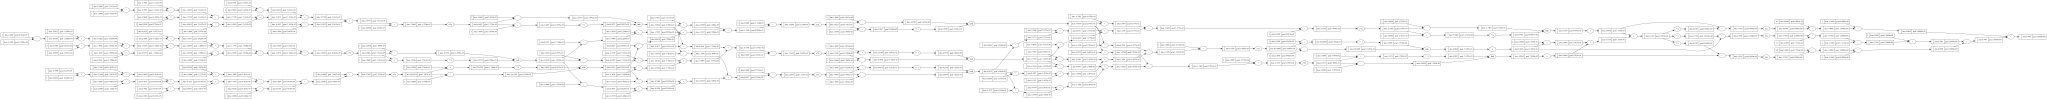

In [ ]:
draw_dot(loss)

# Pytorch

In [ ]:
import torch

In [ ]:
# @title
# this is created by the pytorch
class node:
  def __init__(self):
    w = torch.randn(1, requires_grad=True)
    b = torch.randn(1, requires_grad=True)



In [ ]:
import torch.nn.init as init

class neuron:
  def __init__(self, n_wt):
    # 1. Initialize as empty tensors with requires_grad=True
    self.w = [torch.empty(1, requires_grad=True) for _ in range(n_wt)]
    self.b = torch.empty(1, requires_grad=True)

    # 2. Fill them using the uniform initializer (no_grad is used internally by init functions)
    # This is the cleanest way to set a specific random range
    with torch.no_grad():
        for wei in self.w:
            init.uniform_(wei, a=-1.0, b=1.0)
        init.uniform_(self.b, a=-1.0, b=1.0)

  def __call__(self, _inp):
    return torch.tanh(sum([wei*inp for wei, inp in zip(self.w, _inp)], self.b))

  def parameter(self):
    return self.w + [self.b]

# what option available from shutting down the neuron

### Professional Practice: Xavier (Glorot) Initialization
For `tanh`, the gold standard is Xavier initialization. It sets weights to a variance of $1/N$ (where $N$ is the number of inputs). This mathematically keeps the 'logit' inside that active range of -2 to 2.

In [ ]:
import torch.nn.init as init

class XavierNeuron:
    def __init__(self, n_wt):
        self.w = [torch.empty(1, requires_grad=True) for _ in range(n_wt)]
        self.b = torch.empty(1, requires_grad=True)

        with torch.no_grad():
            # Xavier initialization specifically for tanh
            for wei in self.w:
                init.xavier_uniform_(wei.reshape(1, 1))
            init.zeros_(self.b) # Common practice: start bias at 0

    def __call__(self, x):
        return torch.tanh(sum([wi*xi for wi, xi in zip(self.w, x)], self.b))

### Fighting the 'Dead' Neuron: Leaky ReLU
If a standard ReLU receives a negative signal, its gradient is 0 and it 'dies' forever. **Leaky ReLU** allows a tiny bit of information through even when negative, so it can eventually wake back up.

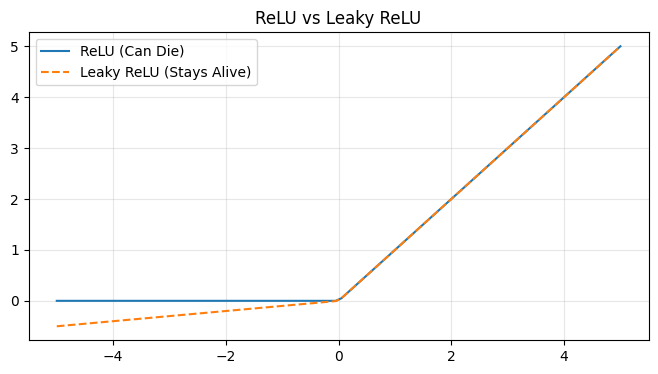

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 100, requires_grad=True)

# Standard ReLU vs Leaky ReLU
y_relu = torch.relu(x)
y_leaky = torch.nn.functional.leaky_relu(x, negative_slope=0.1)

plt.figure(figsize=(8, 4))
plt.plot(x.detach(), y_relu.detach(), label='ReLU (Can Die)')
plt.plot(x.detach(), y_leaky.detach(), label='Leaky ReLU (Stays Alive)', linestyle='--')
plt.title("ReLU vs Leaky ReLU")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Professional Best Practices Model
We will now combine:
1. **Xavier Initialization**: To keep `tanh` in the active zone.
2. **Leaky ReLU**: For hidden layers to prevent 'dead' neurons.
3. **Linear Output**: No activation on the last layer for raw regression values.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.init as init

class ProNeuron:
    def __init__(self, n_inputs, activation='leaky_relu'):
        self.w = torch.empty(n_inputs, 1, requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)
        self.activation = activation

        # Professional Init
        with torch.no_grad():
            if activation == 'tanh':
                init.xavier_uniform_(self.w)
            else:
                init.kaiming_uniform_(self.w, nonlinearity='leaky_relu')

    def __call__(self, x):
        # Ensure x is a tensor
        x = torch.tensor(x) if not isinstance(x, torch.Tensor) else x
        out = x @ self.w + self.b

        if self.activation == 'leaky_relu':
            return torch.nn.functional.leaky_relu(out, negative_slope=0.01)
        elif self.activation == 'tanh':
            return torch.tanh(out)
        else: # Linear / No Activation
            return out

# Test a neuron with NO activation (Linear)
lin_neuron = ProNeuron(n_inputs=3, activation='none')
print(f"Linear Output: {lin_neuron([10.0, 20.0, 30.0]).item():.4f}")

Linear Output: 33.6349


# Continuing the neural layering

In [ ]:
class layer:
  def __init__(self, n_wt, n_neu):
    self.neurons = [neuron(n_wt) for _ in range(n_neu)]

  def __call__(self, _inp):
    return [n(_inp) for n in self.neurons]

  def parameter(self):
    # Use a double comprehension to flatten the list of lists into a single list of tensors
    return [p for n in self.neurons for p in n.parameter()]

In [ ]:
class mlp:
  def __init__(self, n_wt, n_neu, n_layer):
    self.layers = [layer(n_wt if i==0 else n_neu, 1 if i==(n_layer-1) else n_neu) for i in range(n_layer)]


  def __call__(self, _inp):
    for l in self.layers:
      _inp = l(_inp)
    return _inp[0]


  def parameter(self):
    # Direct iteration: 'lyr' represents each layer instance
    # This flattens all parameters from all layers into one list
    return [p for lyr in self.layers for p in lyr.parameter()]

In [ ]:
# Initialize and test the model
mlp_model = mlp(5, 3, 3)
print(f"Total parameters: {len(mlp_model.parameter())}")

# #forw|ard pass
# _inp = [1,2,3]
# mlp_out = mlp_model(_inp)
# print(mlp_out[0].data.item())




Total parameters: 34


In [ ]:
# Forward pass with multiple inputs
_inp_all = [[1, 2, 3, 4, 5],
            [4, 5, 6, 8, 9],
            [3, 9, 18, 11, 12]]

mlp_out = [mlp_model(_inp) for _inp in _inp_all]

# Extract outputs
print("Model Outputs:", [m_out.item() for m_out in mlp_out])

_target = [0.5, 0.1, 0.9]

# Calculate loss
loss = [(e_out - a_out)**2 for a_out, e_out in zip(mlp_out, _target)]
t_loss = sum(loss)
print("Total Loss:", t_loss.item())

# IMPORTANT: We must call backward() to calculate the gradients
# Before this call, p.grad is None
t_loss.backward()

# Now we can safely access .grad
print("Gradients for each parameter:")
print([p.grad.item() for p in mlp_model.parameter()])

with torch.no_grad():
  learning_rate = 0.01
  for p in mlp_model.parameter():
    p.data-= learning_rate * p.grad
    p.grad.zero_()


Model Outputs: [0.43090182542800903, 0.15999145805835724, 0.8093881011009216]
Total Loss: 0.016584044322371483
Gradients for each parameter:
[-0.0009824959561228752, -0.0019651351030915976, -0.0029477740172296762, -0.003930365666747093, -0.004913004580885172, -0.0009826390305534005, 0.0669136494398117, 0.03685945272445679, 0.0068048834800720215, 0.009074777364730835, -0.020978808403015137, -0.030053578317165375, -0.002148018218576908, -0.01392306201159954, -0.026336990296840668, -0.03234749287366867, -0.04305773228406906, -0.010710238479077816, 0.01670893281698227, 0.04303582012653351, -0.0011704117059707642, 0.017045199871063232, -0.012043837457895279, -0.038830071687698364, -0.021632865071296692, -0.012194875627756119, -0.0018691755831241608, -0.022075500339269638, -0.005715187638998032, -0.0020079389214515686, 0.10732945054769516, -0.04518434405326843, 0.07950909435749054, -0.05812729150056839]


### Training the PyTorch MLP
Since the outputs are currently nearly identical, we will run a loop to update the parameters using Gradient Descent. This will show how the model 'learns' to produce different values for different inputs.

In [ ]:
import torch
import numpy as np

# Hyperparameters
learning_rate = 0.3
epochs = 3000

# Re-initialize the model
mlp_model = mlp(5, 10, 3) # Increased hidden units to give the model more 'capacity'
# *******************#
# Explicitly randomize weights more aggressively to break symmetry
with torch.no_grad():
    for p in mlp_model.parameter():
        p.data.uniform_(-1, 1)

_inp_all = torch.tensor([[1.0, 2.0, 3.0, 4.0, 5.0], [4.0, 5.0, 6.0, 8.0, 9.0], [3.0, 9.0, 18.0, 11.0, 12.0]])
_target = torch.tensor([0.5, 0.1, 0.9])

print("Starting training with symmetry breaking...")
for epoch in range(epochs):
    # Forward pass
    outputs = torch.stack([mlp_model(_inp) for _inp in _inp_all]).squeeze()

    # Loss calculation
    loss = torch.mean((outputs - _target)**2)

    # Backward pass
    for p in mlp_model.parameter():
        if p.grad is not None: p.grad.zero_()

    loss.backward()

    # Update parameters
    with torch.no_grad():
        for p in mlp_model.parameter():
            p -= learning_rate * p.grad

    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f} | Outputs: {outputs.detach().numpy()}")

print("\nFinal Targets:", _target.numpy())

Starting training with symmetry breaking...
Epoch    0 | Loss: 2.254452 | Outputs: [-0.9572284  -0.9275217  -0.99315655]
Epoch  500 | Loss: 0.002464 | Outputs: [0.45087963 0.03010203 0.89034265]
Epoch 1000 | Loss: 0.000037 | Outputs: [0.4938265  0.09156144 0.89881796]
Epoch 1500 | Loss: 0.000000 | Outputs: [0.49927977 0.09901909 0.89986265]
Epoch 2000 | Loss: 0.000000 | Outputs: [0.4999163  0.09988613 0.899984  ]
Epoch 2500 | Loss: 0.000000 | Outputs: [0.49998096 0.09997404 0.89999634]
Epoch 2999 | Loss: 0.000000 | Outputs: [0.5000191  0.10002597 0.9000036 ]

Final Targets: [0.5 0.1 0.9]


### Scenario 1: Regression (Predicting a single scalar)
To predict a raw value, we ensure the last layer has only 1 neuron and no Softmax.

In [ ]:
import torch

# Regression MLP: 5 inputs -> Hidden Layers -> 1 Output neuron
reg_mlp = mlp(n_wt=5, n_neu=10, n_layer=3)

_sample_in = [1.0, 2.0, 3.0, 4.0, 5.0]
prediction = reg_mlp(_sample_in)[0] # Returns a single tensor value

print(f"Regression Output (Raw value): {prediction.item():.4f}")

# Error calculation for regression (Mean Squared Error)
target_val = torch.tensor([10.0])
loss = (prediction - target_val)**2
print(f"Regression Loss: {loss.item():.4f}")

Regression Output (Raw value): 0.9462
Regression Loss: 81.9708


### Scenario 2: Classification (Predicting Probabilities)
To categorize data, we use Softmax on the final layer to get a probability distribution.

In [ ]:
def torch_softmax(logits_list):
    # logits_list is a list of tensors from the final layer
    logits_tensor = torch.cat(logits_list)
    return torch.softmax(logits_tensor, dim=0)

# Classification MLP: 5 inputs -> Hidden -> 3 Classes (3 neurons in final layer)
# Note: Your current mlp class forces 1 neuron in the last layer.
# To do multi-class, we'd modify the '1 if i == n_layer-1' logic.

class ClassificationMLP(mlp):
    def __init__(self, n_wt, n_neu, n_classes, n_layer):
        self.layers = [layer(n_wt if i==0 else n_neu, n_classes if i==(n_layer-1) else n_neu) for i in range(n_layer)]

clf_mlp = ClassificationMLP(5, 10, 3, 3)
logits = clf_mlp(_sample_in)
probs = torch_softmax(logits)

print(f"Classification Probabilities (Sum to 1): {probs.tolist()}")
print(f"Predicted Class: {torch.argmax(probs).item()}")

Classification Probabilities (Sum to 1): [0.3442031443119049, 0.31159552931785583, 0.34420132637023926]
Predicted Class: 0


### Scenario 3: Binary Classification
For a 'Yes/No' or 'A/B' choice, we use 1 output neuron and the **Sigmoid** function to get a probability.

### The "Mathematical Collapse" (Why we need Activations)
Without an activation function like `tanh`, no matter how many layers you add, the model remains a simple straight line.

Mathematically: $W_2 	imes (W_1 	imes X) = (W_2 	imes W_1) 	imes X = W_{combined} 	imes X$.

Deep learning only works because activations allow the network to learn non-linear 'shapes'.

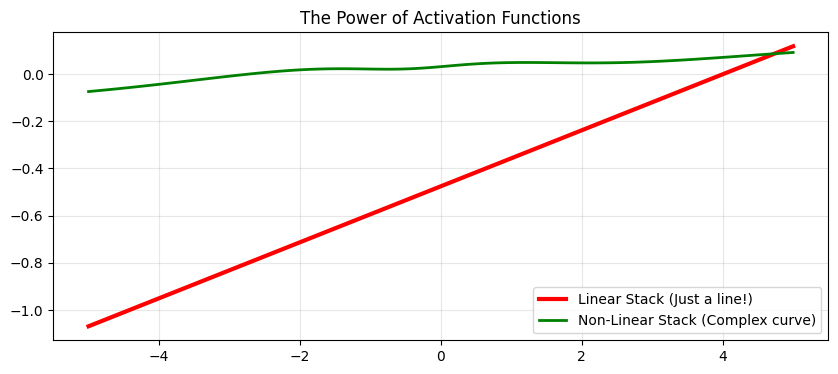

In [ ]:
import torch
import torch.nn as nn

# 1. Linear model (No activation)
# Three layers of size 1, but they behave like one single layer
linear_stack = nn.Sequential(
    nn.Linear(1, 10),
    nn.Linear(10, 10),
    nn.Linear(10, 1)
)

# 2. Non-Linear model (With Tanh)
# These layers work together to create complex curves
nonlinear_stack = nn.Sequential(
    nn.Linear(1, 10),
    nn.Tanh(),
    nn.Linear(10, 10),
    nn.Tanh(),
    nn.Linear(10, 1)
)

x = torch.linspace(-5, 5, 100).reshape(-1, 1)

plt.figure(figsize=(10, 4))
plt.plot(x, linear_stack(x).detach(), label='Linear Stack (Just a line!)', color='red', lw=3)
plt.plot(x, nonlinear_stack(x).detach(), label='Non-Linear Stack (Complex curve)', color='green', lw=2)
plt.title("The Power of Activation Functions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

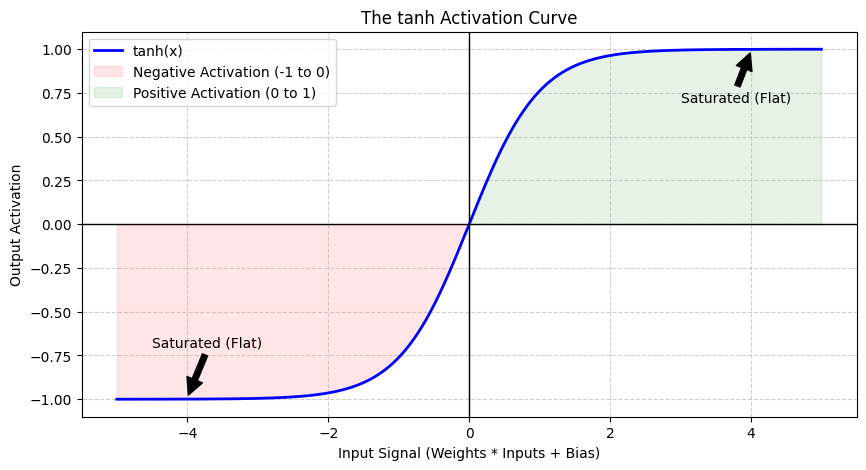

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 200)
y = np.tanh(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, color='blue', lw=2, label='tanh(x)')

# Highlight segments
plt.fill_between(x, y, where=(x < 0), color='red', alpha=0.1, label='Negative Activation (-1 to 0)')
plt.fill_between(x, y, where=(x > 0), color='green', alpha=0.1, label='Positive Activation (0 to 1)')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title("The tanh Activation Curve")
plt.xlabel("Input Signal (Weights * Inputs + Bias)")
plt.ylabel("Output Activation")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.annotate('Saturated (Flat)', xy=(4, 0.99), xytext=(3, 0.7), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Saturated (Flat)', xy=(-4, -0.99), xytext=(-4.5, -0.7), arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

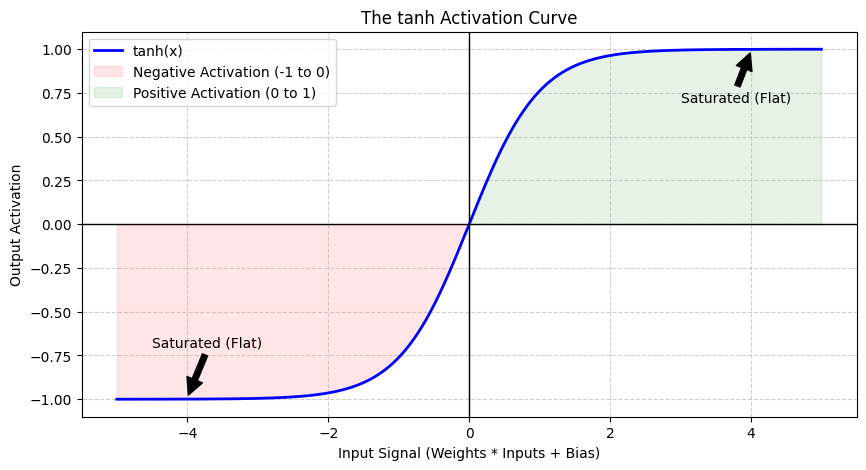

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 200)
y = np.tanh(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, color="blue", lw=2, label="tanh(x)")

# Highlight segments
plt.fill_between(x, y, where=(x < 0), color="red", alpha=0.1, label="Negative Activation (-1 to 0)")
plt.fill_between(x, y, where=(x > 0), color="green", alpha=0.1, label="Positive Activation (0 to 1)")

plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.title("The tanh Activation Curve")
plt.xlabel("Input Signal (Weights * Inputs + Bias)")
plt.ylabel("Output Activation")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.annotate("Saturated (Flat)", xy=(4, 0.99), xytext=(3, 0.7), arrowprops=dict(facecolor="black", shrink=0.05))
plt.annotate("Saturated (Flat)", xy=(-4, -0.99), xytext=(-4.5, -0.7), arrowprops=dict(facecolor="black", shrink=0.05))
plt.show()

In [ ]:
import torch

def test_saturation(input_val, weight_val):
    # Simulate a single neuron: tanh(w * x)
    logit = input_val * weight_val
    activation = torch.tanh(torch.tensor(logit))

    # Calculate gradient (derivative of tanh is 1 - tanh^2)
    gradient = 1 - activation**2

    print(f"Input: {input_val} | Weight: {weight_val} | Logit: {logit:.2f}")
    print(f"Output: {activation:.4f} | Gradient (Learning Speed): {gradient:.4f}")
    print("-" * 50)

print("CASE 1: Large input, but small weight (STEEP/ACTIVE)")
test_saturation(100.0, 0.01)

print("CASE 2: Small input, but huge weight (FLAT/SATURATED)")
test_saturation(0.1, 50.0)

print("CASE 3: Normal range (STEEP/ACTIVE)")
test_saturation(1.0, 1.0)

CASE 1: Large input, but small weight (STEEP/ACTIVE)
Input: 100.0 | Weight: 0.01 | Logit: 1.00
Output: 0.7616 | Gradient (Learning Speed): 0.4200
--------------------------------------------------
CASE 2: Small input, but huge weight (FLAT/SATURATED)
Input: 0.1 | Weight: 50.0 | Logit: 5.00
Output: 0.9999 | Gradient (Learning Speed): 0.0002
--------------------------------------------------
CASE 3: Normal range (STEEP/ACTIVE)
Input: 1.0 | Weight: 1.0 | Logit: 1.00
Output: 0.7616 | Gradient (Learning Speed): 0.4200
--------------------------------------------------


In [ ]:
import torch
import numpy as np

def check_tanh_sensitivity(values):
    print(f"{'Input (x)':<12} | {'Output':<10} | {'Gradient (Slope)':<15} | {'Status'}")
    print("-" * 60)
    for x in values:
        t_x = torch.tensor([float(x)], requires_grad=True)
        y = torch.tanh(t_x)
        y.backward()
        grad = t_x.grad.item()

        status = "Active" if grad > 0.1 else "Saturating" if grad > 0.01 else "Saturated (Flat)"
        print(f"{x:<12.1f} | {y.item():<10.4f} | {grad:<15.4f} | {status}")

# Testing points from 0 to 5
points = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0]
check_tanh_sensitivity(points)

Input (x)    | Output     | Gradient (Slope) | Status
------------------------------------------------------------
0.0          | 0.0000     | 1.0000          | Active
0.5          | 0.4621     | 0.7864          | Active
1.0          | 0.7616     | 0.4200          | Active
2.0          | 0.9640     | 0.0707          | Saturating
3.0          | 0.9951     | 0.0099          | Saturated (Flat)
4.0          | 0.9993     | 0.0013          | Saturated (Flat)
5.0          | 0.9999     | 0.0002          | Saturated (Flat)


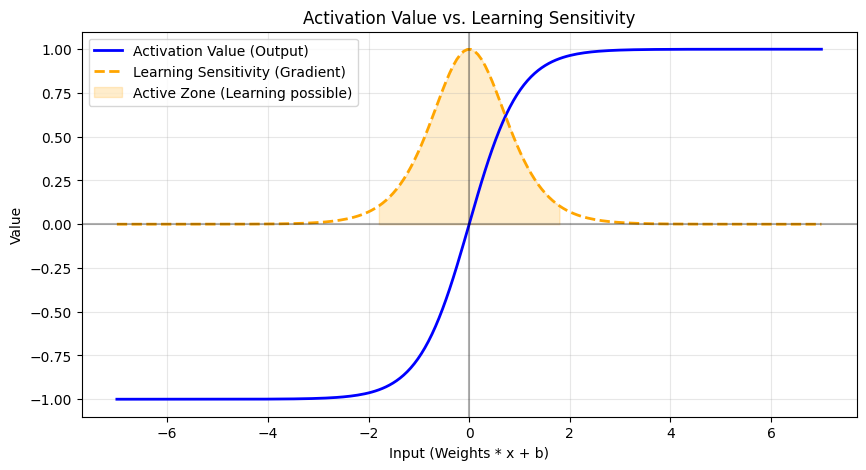

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-7, 7, 200)
y_out = np.tanh(x)
# Gradient of tanh is 1 - tanh^2
y_sensitivity = 1 - y_out**2

plt.figure(figsize=(10, 5))
plt.plot(x, y_out, label='Activation Value (Output)', color='blue', lw=2)
plt.plot(x, y_sensitivity, label='Learning Sensitivity (Gradient)', color='orange', linestyle='--', lw=2)

plt.fill_between(x, 0, y_sensitivity, where=(y_sensitivity > 0.1), color='orange', alpha=0.2, label='Active Zone (Learning possible)')
plt.axvline(0, color='black', alpha=0.3)
plt.axhline(0, color='black', alpha=0.3)

plt.title("Activation Value vs. Learning Sensitivity")
plt.xlabel("Input (Weights * x + b)")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import torch

# Input x -> Neuron A (tanh) -> Neuron B (linear) -> Output
x = torch.tensor([10.0]) # Large input to force saturation in A
wA = torch.tensor([1.0], requires_grad=True)
wB = torch.tensor([1.0], requires_grad=True)

# Forward Pass
activation_A = torch.tanh(x * wA)
output = activation_A * wB

# Target is 0, so error is large
loss = (output - 0)**2
loss.backward()

print(f"Neuron A Output: {activation_A.item():.4f} (Highly Saturated)")
print(f"Loss: {loss.item():.4f}")
print("-" * 30)
print(f"Gradient for wB (Next layer): {wB.grad.item():.4f} <--- Still receives signal!")
print(f"Gradient for wA (Saturated layer): {wA.grad.item():.4f} <--- Learning is BLOCKED (Zero)!")

Neuron A Output: 1.0000 (Highly Saturated)
Loss: 1.0000
------------------------------
Gradient for wB (Next layer): 2.0000 <--- Still receives signal!
Gradient for wA (Saturated layer): 0.0000 <--- Learning is BLOCKED (Zero)!


In [ ]:
import torch

# Binary MLP: 5 inputs -> Hidden Layers -> 1 Output neuron
binary_mlp = mlp(n_wt=5, n_neu=10, n_layer=3)

# Forward pass
logit = binary_mlp(_sample_in)[0]

# Apply Sigmoid: result is always between 0 and 1
probability = torch.sigmoid(logit)

print(f"Raw Logit: {logit.item():.4f}")
print(f"Probability (Sigmoid): {probability.item():.4f}")

# Prediction logic
prediction = 1 if probability > 0.5 else 0
print(f"Predicted Class: {prediction}")

Raw Logit: 0.9897
Probability (Sigmoid): 0.7290
Predicted Class: 1


### Note on Regression + ReLU
As you mentioned, if you are doing regression where the result *must* be positive (like predicting the weight of an object), you would wrap your final output in a ReLU:

You want the raw number. If that number can be anything (like temperature), use 1 neuron + No Activation. If it must be positive (like distance), use 1 neuron + ReLU.

In [ ]:
# Example of forced positive regression
raw_output = reg_mlp(_sample_in)[0]
positive_prediction = torch.relu(raw_output)

print(f"Raw Regression Output: {raw_output.item():.4f}")
print(f"Positive-only Prediction: {positive_prediction.item():.4f}")

Raw Regression Output: 0.9462
Positive-only Prediction: 0.9462


### Simulation: Bringing a 'Dead' Neuron Back to Life
In this example, we start with a weight that makes the input negative (the neuron is 'dead').
- **ReLU**: The gradient is 0. No matter how much we train, it stays dead.
- **Leaky ReLU**: The gradient is 0.01. It will slowly adjust the weight until the neuron 'wakes up'.

In [ ]:
import torch

def simulate_resurrection(activation_type='relu'):
    # Start with a weight that produces a negative input (dead zone)
    x = torch.tensor([10.0])
    w = torch.tensor([-0.5], requires_grad=True) # Output will be -5.0
    target = torch.tensor([5.0]) # We want the output to be 5.0

    lr = 2.0 # High learning rate to see it happen fast

    print(f"--- Testing {activation_type.upper()} ---")
    for i in range(3):
        # Forward
        z = x * w
        if activation_type == 'relu':
            out = torch.relu(z)
        else:
            out = torch.nn.functional.leaky_relu(z, negative_slope=0.1)

        loss = (out - target)**2

        # Backward
        if w.grad is not None: w.grad.zero_()
        loss.backward()

        print(f"Step {i}: Input={z.item():.2f} | Grad={w.grad.item():.4f} | Weight={w.item():.4f}")

        # Update
        with torch.no_grad():
            w -= lr * w.grad
    print("\n")

simulate_resurrection('relu')
simulate_resurrection('leaky_relu')

--- Testing RELU ---
Step 0: Input=-5.00 | Grad=0.0000 | Weight=-0.5000
Step 1: Input=-5.00 | Grad=0.0000 | Weight=-0.5000
Step 2: Input=-5.00 | Grad=0.0000 | Weight=-0.5000


--- Testing LEAKY_RELU ---
Step 0: Input=-5.00 | Grad=-11.0000 | Weight=-0.5000
Step 1: Input=215.00 | Grad=4200.0000 | Weight=21.5000
Step 2: Input=-83785.00 | Grad=-16767.0000 | Weight=-8378.5000




### Modern Professional Activations: GELU, ELU, and Swish
While ReLU is the baseline, modern state-of-the-art models often use these smoother alternatives to improve gradient flow and training stability.

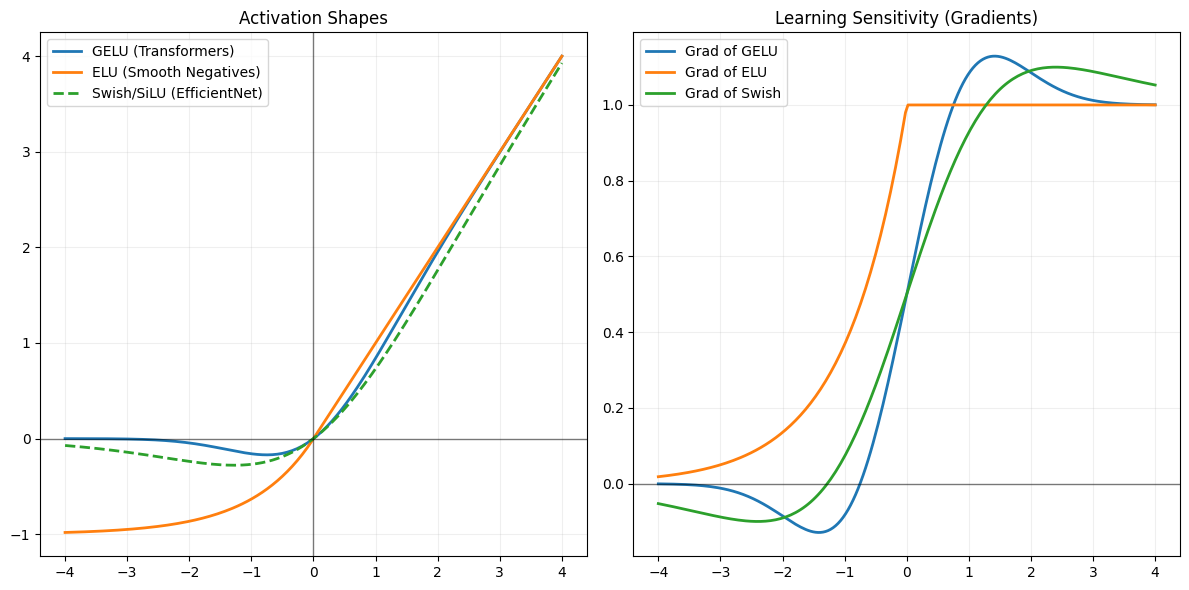

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

x = torch.linspace(-4, 4, 200, requires_grad=True)

# Calculate activations
y_gelu = F.gelu(x)
y_elu = F.elu(x, alpha=1.0)
y_swish = x * torch.sigmoid(x) # Also known as SiLU

plt.figure(figsize=(12, 6))

# Plot Activations
plt.subplot(1, 2, 1)
plt.plot(x.detach(), y_gelu.detach(), label='GELU (Transformers)', lw=2)
plt.plot(x.detach(), y_elu.detach(), label='ELU (Smooth Negatives)', lw=2)
plt.plot(x.detach(), y_swish.detach(), label='Swish/SiLU (EfficientNet)', lw=2, linestyle='--')
plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.axvline(0, color='black', lw=1, alpha=0.5)
plt.title("Activation Shapes")
plt.legend()
plt.grid(True, alpha=0.2)

# Plot Gradients
plt.subplot(1, 2, 2)
for name, y_val in zip(['GELU', 'ELU', 'Swish'], [y_gelu, y_elu, y_swish]):
    # Calculate gradient via autograd
    grad = torch.autograd.grad(y_val.sum(), x, retain_graph=True)[0]
    plt.plot(x.detach(), grad.detach(), label=f'Grad of {name}', lw=2)

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.title("Learning Sensitivity (Gradients)")
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

#### Key Takeaways:
- **Smoothness**: Unlike ReLU's sharp 'elbow' at zero, these functions are smooth (differentiable everywhere). This helps the optimizer find better minima.
- **Negative Saturation**: ELU and GELU saturate on the negative side (like tanh), which can act as a regularizer, but they don't die as easily as ReLU because of the smooth transition.
- **Non-Monotonicity**: Notice **Swish** and **GELU** actually dip below zero briefly even for small positive inputs. This 'bump' helps preserve some information that ReLU would discard.

In [ ]:
import torch
import torch.nn.functional as F

def simulate_modern_recovery(activation_name):
    # Setup: Input is 10, Weight is -0.5 -> Logit is -5.0 (The 'Dead' Zone)
    x = torch.tensor([10.0])
    w = torch.tensor([-0.5], requires_grad=True)
    target = torch.tensor([5.0]) # We want to move the output to +5.0
    lr = 0.5

    print(f"--- Testing {activation_name.upper()} Recovery ---")

    for step in range(5):
        # Forward Pass
        logit = x * w

        if activation_name == 'relu':
            out = torch.relu(logit)
        elif activation_name == 'elu':
            out = F.elu(logit)
        elif activation_name == 'gelu':
            out = F.gelu(logit)
        elif activation_name == 'swish':
            out = logit * torch.sigmoid(logit)

        loss = (out - target)**2

        # Backward Pass
        if w.grad is not None: w.grad.zero_()
        loss.backward()

        # Gradient and Update info
        grad_val = w.grad.item()
        print(f"Step {step}: Logit={logit.item():.2f} | Grad={grad_val:.4f} | Weight={w.item():.4f}")

        # Optimization step
        with torch.no_grad():
            w -= lr * w.grad
    print("\n")

# Run the comparison
simulate_modern_recovery('relu')
simulate_modern_recovery('elu')
simulate_modern_recovery('gelu')
simulate_modern_recovery('swish')

--- Testing RELU Recovery ---
Step 0: Logit=-5.00 | Grad=0.0000 | Weight=-0.5000
Step 1: Logit=-5.00 | Grad=0.0000 | Weight=-0.5000
Step 2: Logit=-5.00 | Grad=0.0000 | Weight=-0.5000
Step 3: Logit=-5.00 | Grad=0.0000 | Weight=-0.5000
Step 4: Logit=-5.00 | Grad=0.0000 | Weight=-0.5000


--- Testing ELU Recovery ---
Step 0: Logit=-5.00 | Grad=-0.8076 | Weight=-0.5000
Step 1: Logit=-0.96 | Grad=-42.9440 | Weight=-0.0962
Step 2: Logit=213.76 | Grad=4175.1694 | Weight=21.3758
Step 3: Logit=-20662.09 | Grad=0.0000 | Weight=-2066.2090
Step 4: Logit=-20662.09 | Grad=0.0000 | Weight=-2066.2090


--- Testing GELU Recovery ---
Step 0: Logit=-5.00 | Grad=0.0007 | Weight=-0.5000
Step 1: Logit=-5.00 | Grad=0.0007 | Weight=-0.5004
Step 2: Logit=-5.01 | Grad=0.0007 | Weight=-0.5007
Step 3: Logit=-5.01 | Grad=0.0007 | Weight=-0.5011
Step 4: Logit=-5.01 | Grad=0.0007 | Weight=-0.5014


--- Testing SWISH Recovery ---
Step 0: Logit=-5.00 | Grad=2.6725 | Weight=-0.5000
Step 1: Logit=-18.36 | Grad=0.0000 | 

### Observations from the Simulation:
- **ReLU**: The gradient is exactly **0.0000**. The weight never changes because the 'elbow' at zero completely cuts off the signal. The neuron is biologically dead.
- **ELU**: It has a smooth exponential tail. Even at -5.0, it provides a tiny gradient that slowly pushes the weight toward the positive side.
- **GELU & Swish**: These are the most interesting. Because of their **non-monotonic bump**, they actually have a gradient that points the weight back toward zero even when deep in the negative zone. They 'search' for the active region much more aggressively than ELU.

# Video 2 of series

MakeMore part 1

### 1. Mount Google Drive

First, you need to mount your Google Drive to your Colab environment. This will allow your notebook to access files stored in your Drive.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Upload Your File to Google Drive

Once your Drive is mounted, you can manually upload your file to any folder within your Google Drive (e.g., to a folder named `Colab Notebooks`).

For example, if you upload a file named `my_document.txt` to the root of your Google Drive, it will be accessible at `/content/drive/MyDrive/my_document.txt`.

### 3. Access the File Content

After uploading, you can read the content of your file. Replace `your_file_name.txt` with the actual name and path of your uploaded file.

In [5]:
# Example: Reading a text file
file_path = '/content/drive/MyDrive/Andrew_karpathy_/names.txt'

try:
    with open(file_path, 'r') as f:
        content = f.read()
    print('File content:')
    print(content)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path and file name are correct.")
except Exception as e:
    print(f"An error occurred: {e}")

# If it's a CSV file, you might use pandas:
# import pandas as pd
# df = pd.read_csv('/content/drive/MyDrive/your_data.csv')
# display(df.head())

File content:
emma
olivia
ava
isabella
sophia
charlotte
mia
amelia
harper
evelyn
abigail
emily
elizabeth
mila
ella
avery
sofia
camila
aria
scarlett
victoria
madison
luna
grace
chloe
penelope
layla
riley
zoey
nora
lily
eleanor
hannah
lillian
addison
aubrey
ellie
stella
natalie
zoe
leah
hazel
violet
aurora
savannah
audrey
brooklyn
bella
claire
skylar
lucy
paisley
everly
anna
caroline
nova
genesis
emilia
kennedy
samantha
maya
willow
kinsley
naomi
aaliyah
elena
sarah
ariana
allison
gabriella
alice
madelyn
cora
ruby
eva
serenity
autumn
adeline
hailey
gianna
valentina
isla
eliana
quinn
nevaeh
ivy
sadie
piper
lydia
alexa
josephine
emery
julia
delilah
arianna
vivian
kaylee
sophie
brielle
madeline
peyton
rylee
clara
hadley
melanie
mackenzie
reagan
adalynn
liliana
aubree
jade
katherine
isabelle
natalia
raelynn
maria
athena
ximena
arya
leilani
taylor
faith
rose
kylie
alexandra
mary
margaret
lyla
ashley
amaya
eliza
brianna
bailey
andrea
khloe
jasmine
melody
iris
isabel
norah
annabelle
valeria
emer

### 4. Process the data
Now that we have the raw content, let's split it into individual names and check how many we have.

In [6]:
words = content.splitlines()
print(f"First 10 names: {words[:10]}")
print(f"Total number of names: {len(words)}")
print(f"Shortest name length: {min(len(w) for w in words)}")
print(f"Longest name length: {max(len(w) for w in words)}")

First 10 names: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Total number of names: 32033
Shortest name length: 2
Longest name length: 15


### 5. Bigram Exploration
A bigram is just a pair of characters. We also use special start (`<S>`) and end (`<E>`) tokens to tell the model when a name begins and ends.

In [7]:
b = {}
for w in words[:3]: # Let's look at the first 3 names
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        print(f"{ch1} {ch2}")

print("\nBigram counts for the first 3 names:")
print(b)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>

Bigram counts for the first 3 names:
{('<S>', 'e'): 1, ('e', 'm'): 1, ('m', 'm'): 1, ('m', 'a'): 1, ('a', '<E>'): 3, ('<S>', 'o'): 1, ('o', 'l'): 1, ('l', 'i'): 1, ('i', 'v'): 1, ('v', 'i'): 1, ('i', 'a'): 1, ('<S>', 'a'): 1, ('a', 'v'): 1, ('v', 'a'): 1}


### 6. Aggregate Bigrams into a Matrix
We will now use `torch` to create a 28x28 matrix (for 26 letters plus our start/end token) to store the counts of every possible character pair in the dataset.

In [8]:
import torch

# Create a mapping from characters to integers
s = ''.join(words)
print(s)
a = set(s)
c= list(a)
print(a)
print(c)

chars = sorted(c)
print(chars)
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
print(stoi)
itos = {i:s for s,i in stoi.items()}
print(itos)

# Initialize the count matrix
N = torch.zeros((27, 27), dtype=torch.int32)

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

print("Matrix N initialized with counts for all names.")

...
{'v', 'y', 'e', 'r', 'c', 'p', 'u', 'h', 'f', 'o', 'q', 'k', 'g', 'd', 'm', 'i', 'a', 't', 'w', 's', 'x', 'j', 'n', 'l', 'z', 'b'}
['v', 'y', 'e', 'r', 'c', 'p', 'u', 'h', 'f', 'o', 'q', 'k', 'g', 'd', 'm', 'i', 'a', 't', 'w', 's', 'x', 'j', 'n', 'l', 'z', 'b']
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
Matrix N initialized with counts for all names.


In [9]:
# @title
# 1. Direct Assignment (What you used)
test_dict = {}
test_dict['name'] = 'Python'

# 2. Update Method
test_dict.update({'version': 3.12, 'type': 'Language'})

# 3. setdefault (Only sets if key is missing)
test_dict.setdefault('name', 'Java') # 'name' is already 'Python', so nothing changes
test_dict.setdefault('status', 'Active') # 'status' is new, so it is added

# 4. dict.fromkeys (Initialize keys with a specific value)
new_keys = ['a', 'b', 'c']
zeros_dict = dict.fromkeys(new_keys, 0)

print(f"Modified test_dict: {test_dict}")
print(f"Initialized zeros_dict: {zeros_dict}")

Modified test_dict: {'name': 'Python', 'version': 3.12, 'type': 'Language', 'status': 'Active'}
Initialized zeros_dict: {'a': 0, 'b': 0, 'c': 0}


In [10]:
# @title
import torch

# 1. String: Iterates character by character
sentence = "hello"
print(f"Set from string: {set(sentence)}")

# 2. List of Tuples: Treats each tuple as a single unique item
tuple_list = [(1, 2), (1, 2), (3, 4)]
print(f"Set from tuples: {set(tuple_list)}")

# 3. Matrix: Must be converted to tuples of tuples to be hashable
matrix = [[1, 0], [0, 1]]
try:
    set(matrix) # This will fail because lists are mutable
except TypeError as e:
    print(f"Direct matrix error: {e}")

# Correct way for matrix: Convert nested structure to tuples
hashable_matrix = tuple(map(tuple, matrix))
matrix_set = {hashable_matrix}
print(f"Set containing a matrix (as nested tuples): {matrix_set}")

Set from string: {'h', 'e', 'o', 'l'}
Set from tuples: {(1, 2), (3, 4)}
Direct matrix error: unhashable type: 'list'
Set containing a matrix (as nested tuples): {((1, 0), (0, 1))}


### 7. Visualize the Bigram Counts
Let's plot this matrix to see which character transitions are the most common.

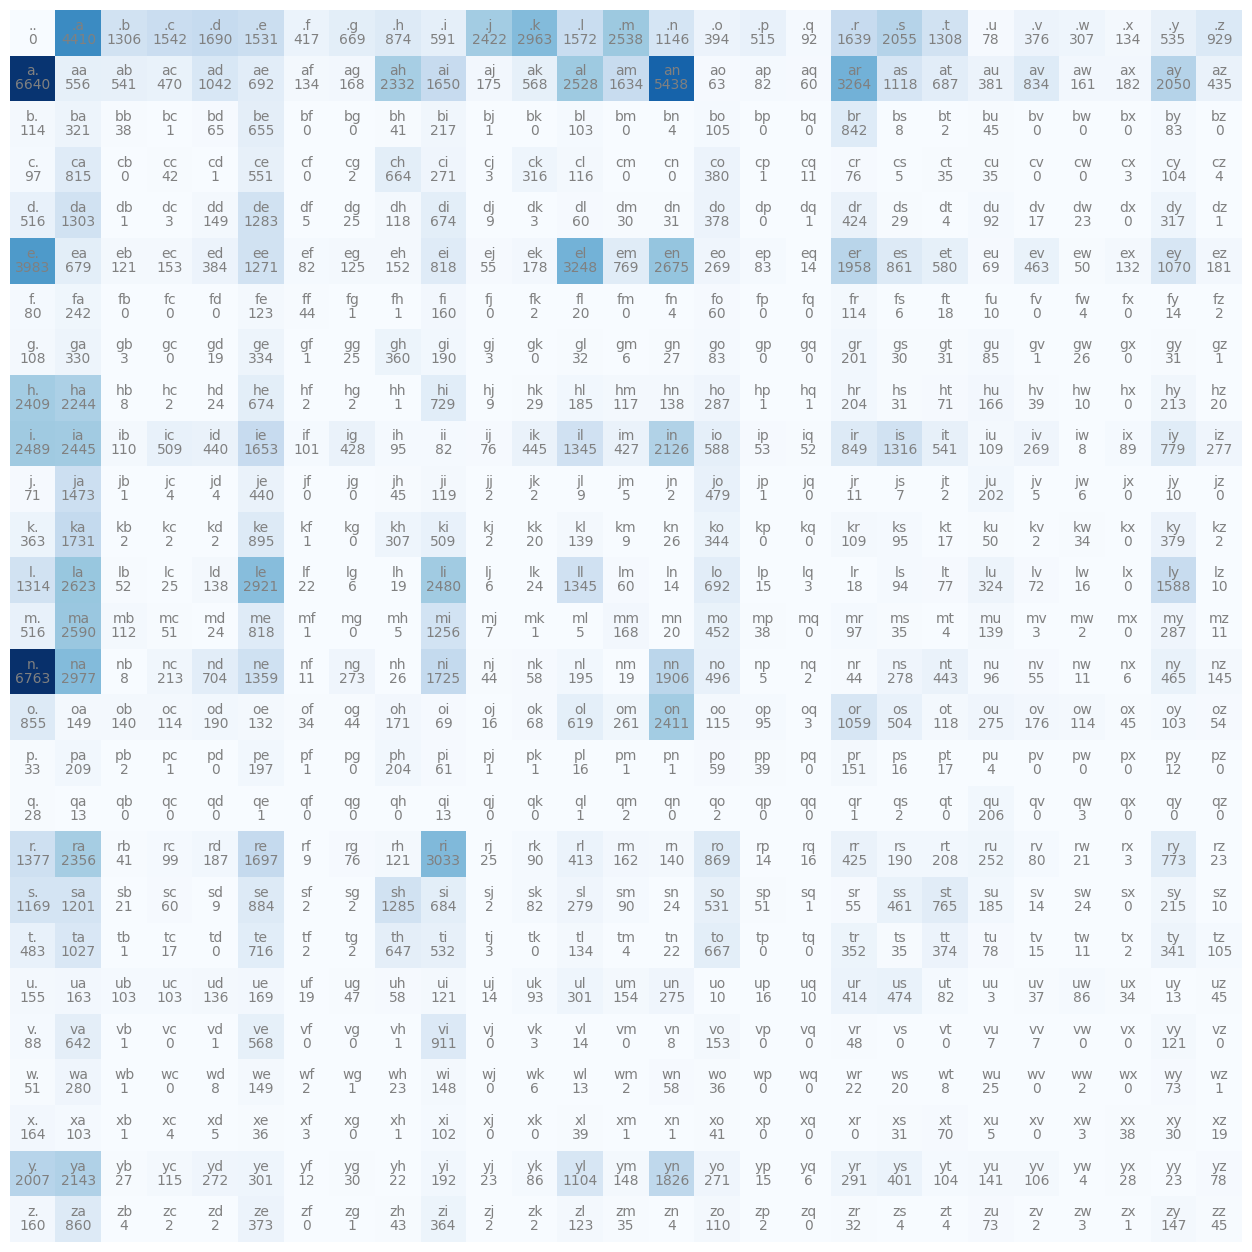

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

### 8. Normalize and Sample
We convert the counts in matrix `N` into probabilities `P`. We add 1 to all counts (smoothing) to ensure no bigram has a zero probability, then divide each row by its sum.

In [12]:
# Model smoothing: add 1 to counts to avoid 0 probabilities
# print(N)
P = (N+1).float()
# print(P)
P /= P.sum(1, keepdim=True)

g = torch.Generator().manual_seed(2147483647)

print("Sampling 10 names from the bigram model:")
for i in range(10):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

Sampling 10 names from the bigram model:
cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


tensor([1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2,
        1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 0, 1, 2, 1, 1, 1, 2, 1,
        1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1,
        1, 1, 1, 1, 2, 1, 1, 2, 1, 0, 2, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 2,
        1, 1, 1, 2, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 1, 1, 1, 2,
        1, 2, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 0, 2, 2, 1,
        1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 2, 1,
        2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
        2, 0, 1, 1, 1, 1, 1, 1, 2, 0, 1,

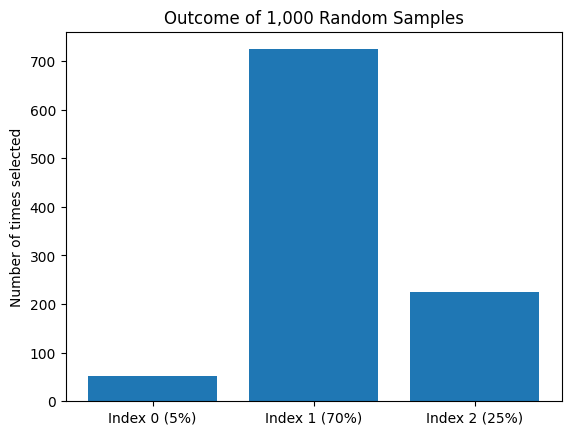

In [13]:
import torch
import matplotlib.pyplot as plt

# Define a distribution: Index 0 (5%), Index 1 (70%), Index 2 (25%)
p = torch.tensor([0.05, 0.70, 0.25])

# Sample 1,000 times
g = torch.Generator().manual_seed(42)
samples = torch.multinomial(p, num_samples=1000, replacement=True, generator=g)
print(samples)
# Count how many times each index was actually chosen
counts = samples.bincount()

print(f"Target Probabilities: {p.tolist()}")
print(f"Actual Percentages:  {[c.item()/1000 for c in counts]}")

# Visualize
plt.bar(['Index 0 (5%)', 'Index 1 (70%)', 'Index 2 (25%)'], counts)
plt.title("Outcome of 1,000 Random Samples")
plt.ylabel("Number of times selected")
plt.show()

Original Probabilities: [0.05000000074505806, 0.699999988079071, 0.25]
Actual Counts (out of 1000): [47, 720, 233]


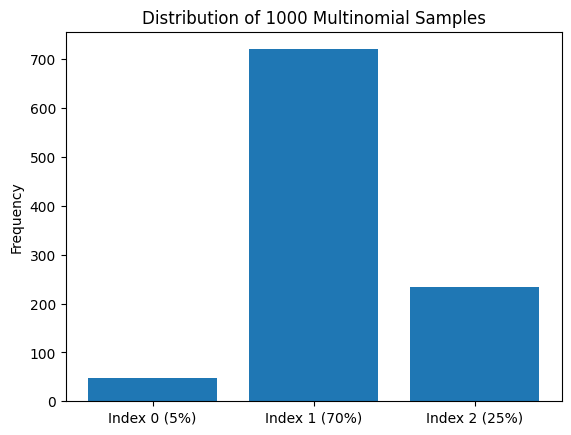

In [14]:
import torch
import matplotlib.pyplot as plt

# Define a distribution: Index 1 is 70%, Index 2 is 25%, Index 0 is 5%
p = torch.tensor([0.05, 0.70, 0.25])

# Sample 1000 times with num_samples=1
samples = []
g = torch.Generator().manual_seed(42)
for _ in range(1000):
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    samples.append(ix)

# Count frequencies
counts = torch.tensor(samples).bincount()

print(f"Original Probabilities: {p.tolist()}")
print(f"Actual Counts (out of 1000): {counts.tolist()}")

plt.bar(['Index 0 (5%)', 'Index 1 (70%)', 'Index 2 (25%)'], counts)
plt.title("Distribution of 1000 Multinomial Samples")
plt.ylabel("Frequency")
plt.show()

### 9. Evaluate the Model (Loss Function)
We calculate the log likelihood of the entire dataset. The goal of training is to maximize the likelihood of the data, which is equivalent to minimizing the Negative Log Likelihood (NLL).

In [15]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

print(f'log_likelihood={log_likelihood}')
nll = -log_likelihood
print(f'nll={nll}')
print(f'Average NLL (Loss): {nll/n:.4f}')

log_likelihood=-559951.5625
nll=559951.5625
Average NLL (Loss): 2.4544


### 9. Evaluate the Model (Loss Function)
We calculate the log likelihood of the entire dataset. The goal of training is to maximize the likelihood of the data, which is equivalent to minimizing the Negative Log Likelihood (NLL).

In [16]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'Average NLL (Loss): {nll/n:.4f}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
Average NLL (Loss): 2.4544


### 10. Neural Network Approach: Dataset Preparation
We will now create a training set of bigrams $(x, y)$. Given a character $x$, we want the network to predict the next character $y$.

In [17]:
import torch.nn.functional as F

# Create the training set for all bigrams
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(f'Number of examples: {num}')

# We use one-hot encoding to feed these integers into a neural network
xenc = F.one_hot(xs, num_classes=27).float()
print(f'Shape of one-hot encoded input: {xenc.shape}')

Number of examples: 228146
Shape of one-hot encoded input: torch.Size([228146, 27])


### 11. The Linear Layer & Forward Pass
We initialize random weights $W$ and perform the forward pass: $x @ W$. We then interpret the results as log-counts (logits) and pass them through a softmax function to get a probability distribution.

In [18]:
# Randomly initialize 27 neurons' weights, each receiving 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

# Forward pass: predict log-counts
logits = xenc @ W

# Softmax layer
counts = logits.exp() # equivalent to the N matrix
probs = counts / counts.sum(1, keepdims=True)

print(f"Output shape: {probs.shape}")
print(f"Sample probabilities for the first example: {probs[0]}")

Output shape: torch.Size([228146, 27])
Sample probabilities for the first example: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
       grad_fn=<SelectBackward0>)


### 11. The Linear Layer & Forward Pass
We initialize random weights $W$ and perform the forward pass: $x @ W$. We then interpret the results as log-counts (logits) and pass them through a softmax function to get a probability distribution.

In [19]:
# Randomly initialize 27 neurons' weights, each receiving 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

# Forward pass: predict log-counts
logits = xenc @ W

# Softmax layer
counts = logits.exp() # equivalent to the N matrix
probs = counts / counts.sum(1, keepdims=True)

print(f"Output shape: {probs.shape}")
print(f"Sample probabilities for the first example: {probs[0]}")

Output shape: torch.Size([228146, 27])
Sample probabilities for the first example: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
       grad_fn=<SelectBackward0>)


### 12. Loss Function & Backward Pass
We calculate the Negative Log Likelihood loss for the neural network. We then use autograd to compute the gradients and update the weight matrix $W$ using gradient descent.

In [20]:
# 1. Compute Loss
# We extract the probability the model assigned to the actual next character (ys)
probs_correct = probs[torch.arange(num), ys]
loss = -probs_correct.log().mean()
print(f'Initial Loss: {loss.item():.4f}')

# 2. Backward Pass
W.grad = None # Always reset gradients to zero before backward
loss.backward()

# 3. Update Weights (Gradient Descent)
# We manually update the data and use a learning rate of 50
with torch.no_grad():
    W.data -= 50 * W.grad

# Check the loss again to see improvement
logits_new = xenc @ W
counts_new = logits_new.exp()
probs_new = counts_new / counts_new.sum(1, keepdims=True)
loss_new = -probs_new[torch.arange(num), ys].log().mean()
print(f'Loss after one update step: {loss_new.item():.4f}')

Initial Loss: 3.7590
Loss after one update step: 3.3711


### 12. Loss Function & Backward Pass
We calculate the Negative Log Likelihood loss for the neural network. We then use autograd to compute the gradients and update the weight matrix $W$.

In [25]:
# 1. Compute Loss
# We want the probability the model assigns to the actual next character (ys)
probs_correct = probs[torch.arange(num), ys]
loss = -probs_correct.log().mean()
print(f'Initial Loss: {loss.item():.4f}')

# 2. Backward Pass
W.grad = None # reset gradients
loss.backward()

# 3. Update Weights (Gradient Descent)
with torch.no_grad():
    W.data -= 50 * W.grad

# Check loss again after one update
logits_new = xenc @ W
counts_new = logits_new.exp()
probs_new = counts_new / counts_new.sum(1, keepdims=True)
loss_new = -probs_new[torch.arange(num), ys].log().mean()
print(f'Loss after one step: {loss_new.item():.4f}')

Initial Loss: 2.4750


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

### 13. Full Training Loop
We now combine the forward pass, backward pass, and parameter update into a single loop to optimize the weights $W$ over many iterations.

In [22]:
# Create the dataset
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1, ix2 = stoi[ch1], stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs, ys = torch.tensor(xs), torch.tensor(ys)
num = xs.nelement()

# Initialize weights
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

# Gradient descent loop
for k in range(100):
    # 1. Forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)

    # 2. Loss (with small regularization to match smoothing)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
    if k % 10 == 0:
        print(f'Iteration {k:3d} | Loss: {loss.item():.4f}')

    # 3. Backward pass
    W.grad = None
    loss.backward()

    # 4. Update
    W.data += -50 * W.grad

print(f'Final Loss: {loss.item():.4f}')

Iteration   0 | Loss: 3.7686
Iteration  10 | Loss: 2.6965
Iteration  20 | Loss: 2.5823
Iteration  30 | Loss: 2.5414
Iteration  40 | Loss: 2.5213
Iteration  50 | Loss: 2.5099
Iteration  60 | Loss: 2.5027
Iteration  70 | Loss: 2.4979
Iteration  80 | Loss: 2.4944
Iteration  90 | Loss: 2.4919
Final Loss: 2.4901


### 13. Full Training Loop
We now combine the forward pass, backward pass, and parameter update into a single loop to optimize the weights $W$ over many iterations.

In [26]:
# Create the dataset
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1, ix2 = stoi[ch1], stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs, ys = torch.tensor(xs), torch.tensor(ys)
num = xs.nelement()

# Initialize weights
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

# Gradient descent loop
for k in range(100):
    # 1. Forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)

    # 2. Loss (with small regularization to match smoothing)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
    if k % 10 == 0:
        print(f'Iteration {k:3d} | Loss: {loss.item():.4f}')

    # 3. Backward pass
    W.grad = None
    loss.backward()

    # 4. Update
    W.data += -50 * W.grad

print(f'Final Loss: {loss.item():.4f}')

Iteration   0 | Loss: 3.7686
Iteration  10 | Loss: 2.6965
Iteration  20 | Loss: 2.5823
Iteration  30 | Loss: 2.5414
Iteration  40 | Loss: 2.5213
Iteration  50 | Loss: 2.5099
Iteration  60 | Loss: 2.5027
Iteration  70 | Loss: 2.4979
Iteration  80 | Loss: 2.4944
Iteration  90 | Loss: 2.4919
Final Loss: 2.4901


### 10. Neural Network Approach: Dataset Preparation
We will now create a training set of bigrams $(x, y)$. Given a character $x$, we want the network to predict the next character $y$.

In [27]:
# Create the training set for all bigrams
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(f'Number of examples: {num}')

# We use one-hot encoding to feed these integers into a neural network
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
print(f'Shape of one-hot encoded input: {xenc.shape}')

Number of examples: 228146
Shape of one-hot encoded input: torch.Size([228146, 27])


### Video 3: Multi-Layer Perceptron (MLP) Implementation
We are now moving beyond Bigrams. Instead of $P(y|x)$, we will predict $P(y | x_{t-1}, x_{t-2}, x_{t-3})$.

First, let's build the dataset where `X` contains the indices of 3 characters and `Y` is the index of the character that follows them.

In [30]:
# Re-loading words and building the full dataset
file_path = '/content/drive/MyDrive/Andrew_karpathy_/names.txt'
with open(file_path, 'r') as f:
    words = f.read().splitlines()

block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

print(f"Full dataset input shape: {X.shape}")
print(f"Full dataset target shape: {Y.shape}")

Full dataset input shape: torch.Size([228146, 3])
Full dataset target shape: torch.Size([228146])


### Step 1: Character Embeddings
We initialize a lookup table `C`. Each of the 27 characters will be represented by a 2-dimensional vector. This allows the network to learn which letters are 'similar' (like vowels).

In [31]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)

# Embedding lookup for all inputs
emb = C[X] # (N, 3, 2)

# Hidden Layer initialization
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)

# We flatten the context embeddings from (N, 3, 2) to (N, 6) to pass into the linear layer
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

# Output Layer
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
logits = h @ W2 + b2

# Loss calculation (Cross Entropy)
loss = torch.nn.functional.cross_entropy(logits, Y)
print(f"Initial MLP Loss: {loss.item():.4f}")

Initial MLP Loss: 19.5052


In [33]:
# Training parameters
max_steps = 200000
batch_size = 32
lossi = []

# Group parameters for the optimizer
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

for i in range(max_steps):
    # Minibatch construct
    ix = torch.randint(0, X.shape[0], (batch_size,), generator=g)
    Xb, Yb = X[ix], Y[ix]

    # Forward pass
    emb = C[Xb] # (batch_size, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (batch_size, 100)
    logits = h @ W2 + b2 # (batch_size, 27)
    loss = torch.nn.functional.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update (Learning rate decay)
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # Track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

print(f"Final training loss: {loss.item():.4f}")

      0/ 200000: 2.4731
  10000/ 200000: 2.0162
  20000/ 200000: 2.4135
  30000/ 200000: 2.3440
  40000/ 200000: 2.1618
  50000/ 200000: 2.2866
  60000/ 200000: 2.2020
  70000/ 200000: 2.1787
  80000/ 200000: 2.3833
  90000/ 200000: 2.4424
 100000/ 200000: 2.5548
 110000/ 200000: 2.1939
 120000/ 200000: 2.1488
 130000/ 200000: 2.0650
 140000/ 200000: 2.5197
 150000/ 200000: 2.0806
 160000/ 200000: 2.1005
 170000/ 200000: 2.2947
 180000/ 200000: 2.3399
 190000/ 200000: 2.3246
Final training loss: 2.2122


### Video 3 Completion: Evaluation, Visualization, and Sampling
Now that the MLP is trained, let's evaluate its performance and visualize the learned embeddings.

In [37]:
@torch.no_grad()
def calculate_loss():
    emb = C[X] # (N, block_size, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = torch.nn.functional.cross_entropy(logits, Y)
    return loss.item()

print(f"Final Loss on entire dataset: {calculate_loss():.4f}")

Final Loss on entire dataset: 2.2131


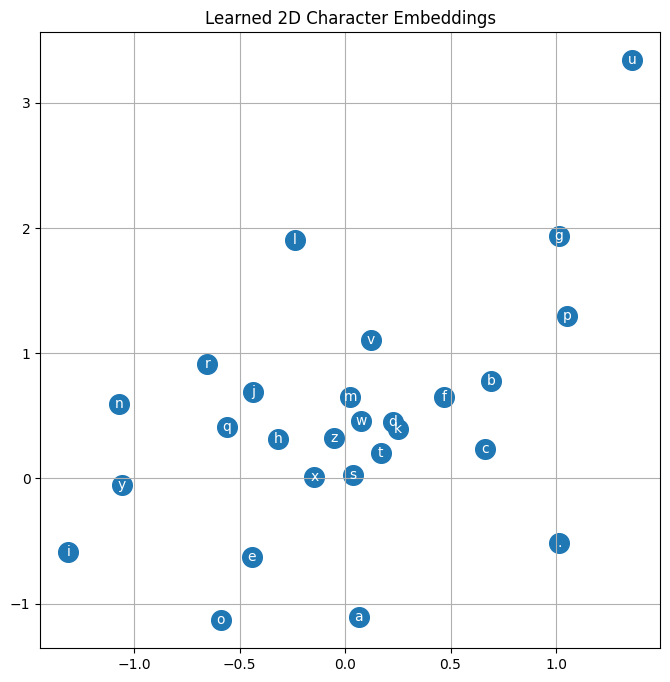

In [38]:
# Visualize the 2D embeddings learned by the model
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')
plt.title("Learned 2D Character Embeddings")
plt.show()

In [39]:
# Sample from the MLP model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
      emb = C[torch.tensor([context])] # (1, block_size, 2)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = torch.nn.functional.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0: break

    print(''.join(itos[i] for i in out[:-1]))

carmah
ami
havi
kimrix
thil
salassie
mahnen
amerric
kaqni
nellara


In [32]:
# Training parameters
max_steps = 200000
batch_size = 32
lossi = []

# Group parameters for the optimizer
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

for i in range(max_steps):
    # Minibatch construct
    ix = torch.randint(0, X.shape[0], (batch_size,), generator=g)
    Xb, Yb = X[ix], Y[ix]

    # Forward pass
    emb = C[Xb] # embed the characters into vectors
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = torch.nn.functional.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update (Learning rate decay)
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # Track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

print(f"Final training loss: {loss.item():.4f}")

      0/ 200000: 21.8058
  10000/ 200000: 2.3318
  20000/ 200000: 2.8365
  30000/ 200000: 2.3490
  40000/ 200000: 2.8789
  50000/ 200000: 2.5850
  60000/ 200000: 2.4010
  70000/ 200000: 2.4454
  80000/ 200000: 2.6543
  90000/ 200000: 2.3491
 100000/ 200000: 2.9214
 110000/ 200000: 2.3761
 120000/ 200000: 2.5690
 130000/ 200000: 2.0809
 140000/ 200000: 2.5091
 150000/ 200000: 1.7620
 160000/ 200000: 2.3735
 170000/ 200000: 2.2463
 180000/ 200000: 2.0382
 190000/ 200000: 2.0445
Final training loss: 2.6517


### Final Evaluation and Visualization (Wrapping up Video 3)
Now that the model is trained, let's see what it actually learned.

In [34]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X, Y), # Using full X,Y for simplicity since split wasn't explicitly defined earlier
    }[split]
    emb = C[x] # (N, block_size, n_emb)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, itos_size)
    loss = torch.nn.functional.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')

train loss: 2.2131


Text(0.5, 1.0, '2D Character Embeddings learned by MLP')

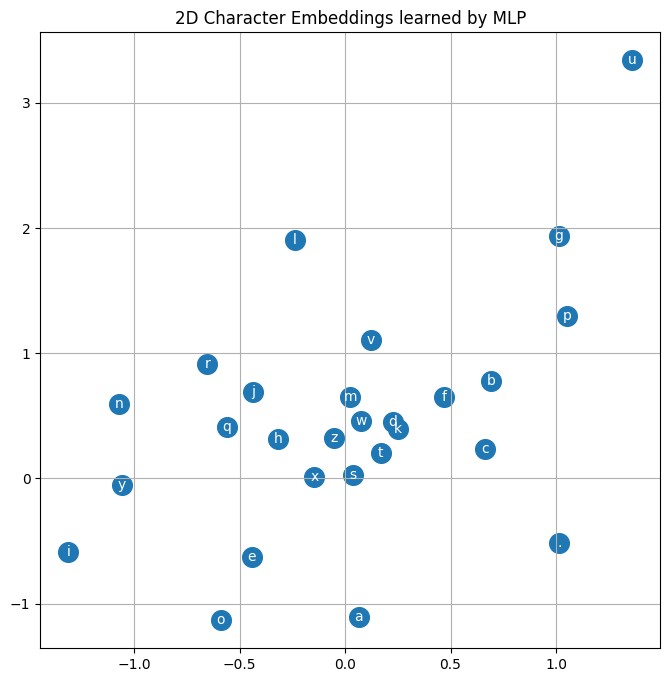

In [35]:
# Visualize the character embeddings learned by the MLP
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')
plt.title("2D Character Embeddings learned by MLP")

In [36]:
# Sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(10):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1, block_size, d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = torch.nn.functional.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmah.
ami.
havi.
kimrix.
thil.
salassie.
mahnen.
amerric.
kaqni.
nellara.


## Video 4: Manual Backpropagation (Becoming a Backprop Ninja)
We will now rewrite the forward pass to be more explicit and then derive the gradients for each intermediate variable by hand.

In [40]:
# Initialize parameters for the Ninja phase
n_emb = 2
n_hidden = 100

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, n_emb),            generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * (5/3)/((n_emb * block_size)**0.5)
b1 = torch.randn(n_hidden,               generator=g) * 0.1
W2 = torch.randn((n_hidden, 27),         generator=g) * 0.1
b2 = torch.randn(27,                     generator=g) * 0.1

parameters = [C, W1, b1, W2, b2]
for p in parameters: p.requires_grad = True

# Get a single batch for gradient verification
batch_size = 32
n = batch_size
ix = torch.randint(0, X.shape[0], (batch_size,), generator=g)
Xb, Yb = X[ix], Y[ix]

# Forward pass (broken down into simple steps for manual backprop)
emb = C[Xb] # (32, 3, 2)
embcat = emb.view(emb.shape[0], -1) # (32, 6)
# Layer 1
hpreact = embcat @ W1 + b1 # (32, 100)
h = torch.tanh(hpreact) # (32, 100)
# Layer 2
logits = h @ W2 + b2 # (32, 27)
# Cross-entropy loss
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtraction for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[torch.arange(n), Yb].mean()

# PyTorch backprop to get reference gradients
for p in parameters: p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, norm_logits, logit_maxes, logits, h, hpreact, embcat, emb, C, W1, b1, W2, b2]:
    t.retain_grad()
loss.backward()

print(f"Initial Batch Loss: {loss.item():.4f}")

Initial Batch Loss: 3.7933


### Manual Backpropagation: Step 1
We'll verify our manual gradients against PyTorch's autograd using a helper function.

In [41]:
def cmp(s, dt, t):
  ex = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | maxdiff: {maxdiff:e}')

# 1. Backprop through loss = -logprobs[range(n), Yb].mean()
# dloss/dlogprobs
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[torch.arange(n), Yb] = -1.0/n
cmp('logprobs', dlogprobs, logprobs)

# 2. Backprop through logprobs = probs.log()
# dloss/dprobs = dloss/dlogprobs * dlogprobs/dprobs
# dlogprobs/dprobs = 1/probs
dprobs = (1.0 / probs) * dlogprobs
cmp('probs', dprobs, probs)

# 3. Backprop through probs = counts * counts_sum_inv
# This is a product rule: d(u*v) = du*v + u*dv
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)

dcounts = counts_sum_inv * dprobs
# Note: dcounts also gets a contribution from counts_sum, so we'll finish it in the next step

logprobs        | exact: True  | maxdiff: 0.000000e+00
probs           | exact: True  | maxdiff: 0.000000e+00
counts_sum_inv  | exact: True  | maxdiff: 0.000000e+00


### Manual Backpropagation: Step 2
Continuing through the softmax denominator and the exponential counts.

In [42]:
# 4. Backprop through counts_sum_inv = counts_sum**-1
# dloss/dcounts_sum = dloss/dcounts_sum_inv * dcounts_sum_inv/dcounts_sum
# dcounts_sum_inv/dcounts_sum = -1 * counts_sum**-2
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
cmp('counts_sum', dcounts_sum, counts_sum)

# 5. Backprop through counts_sum = counts.sum(1, keepdim=True)
# The sum operation broadcasts the gradient back to all elements
dcounts = torch.ones_like(counts) * dcounts_sum
# Add the contribution from step 3: dcounts = counts_sum_inv * dprobs
dcounts += counts_sum_inv * dprobs
cmp('counts', dcounts, counts)

# 6. Backprop through counts = norm_logits.exp()
# dloss/dnorm_logits = dloss/dcounts * dcounts/dnorm_logits
# dcounts/dnorm_logits = exp(norm_logits) = counts
dnorm_logits = counts * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)

counts_sum      | exact: True  | maxdiff: 0.000000e+00
counts          | exact: True  | maxdiff: 0.000000e+00
norm_logits     | exact: True  | maxdiff: 0.000000e+00


### Manual Backpropagation: Step 3 (Final)
Backpropagating through the linear layers, tanh activation, and character embeddings to complete the Ninja challenge.

In [43]:
# 7. Backprop through norm_logits = logits - logit_maxes
# dloss/dlogits = dloss/dnorm_logits * dnorm_logits/dlogits + dloss/dlogit_maxes * dlogit_maxes/dlogits
# dlogit_maxes contribution is actually 0 because the sum of dnorm_logits is 0 (check Softmax derivative property)
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=27) * dlogit_maxes
cmp('logits', dlogits, logits)

# 8. Backprop through logits = h @ W2 + b2
dh = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)

# 9. Backprop through h = torch.tanh(hpreact)
# dloss/dhpreact = dh * (1 - h^2)
dhpreact = (1.0 - h**2) * dh
cmp('hpreact', dhpreact, hpreact)

# 10. Backprop through hpreact = embcat @ W1 + b1
dembcat = dhpreact @ W1.T
dW1 = embcat.T @ dhpreact
db1 = dhpreact.sum(0)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)

# 11. Backprop through embcat = emb.view(32, 6)
demb = dembcat.view(emb.shape)
cmp('emb', demb, emb)

# 12. Backprop through emb = C[Xb]
dC = torch.zeros_like(C)
for i in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[i, j]
        dC[ix] += demb[i, j]
cmp('C', dC, C)

print("\n--- Manual Backpropagation Successfully Verified! ---")

logits          | exact: True  | maxdiff: 0.000000e+00
h               | exact: True  | maxdiff: 0.000000e+00
W2              | exact: True  | maxdiff: 0.000000e+00
b2              | exact: True  | maxdiff: 0.000000e+00
hpreact         | exact: True  | maxdiff: 4.656613e-10
embcat          | exact: True  | maxdiff: 3.725290e-09
W1              | exact: True  | maxdiff: 3.725290e-09
b1              | exact: True  | maxdiff: 2.793968e-09
emb             | exact: True  | maxdiff: 3.725290e-09
C               | exact: True  | maxdiff: 4.656613e-09

--- Manual Backpropagation Successfully Verified! ---


## Video 5: Building WaveNet (Hierarchical MLP)
We are now refactoring our code into a more modular, PyTorch-like API. This will make it easier to build deeper, more complex architectures like WaveNet.

In [50]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0, 1)
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim), generator=g)

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [51]:
n_embd = 10
n_hidden = 68
block_size = 8

# Re-build dataset for larger context (WaveNet typically uses 8)
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X, Y = torch.tensor(X), torch.tensor(Y)

# Define the Hierarchical WaveNet model
model = Sequential([
    Embedding(27, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, 27),
])

parameters = model.parameters()
for p in parameters: p.requires_grad = True
print(f"Total parameters: {sum(p.nelement() for p in parameters)}")

Total parameters: 22397


In [73]:
import random

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(f"Splits created: Train {len(Xtr)}, Val {len(Xval)}, Test {len(Xte)}")

Splits created: Train 182691, Val 22793, Test 22662


In [74]:
# Training the Hierarchical WaveNet
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):
    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    logits = model(Xb)
    loss = torch.nn.functional.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters: p.grad = None
    loss.backward()

    # Learning rate decay
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters: p.data += -lr * p.grad

    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/  20000: 1.5517
   1000/  20000: 1.9620
   2000/  20000: 1.8251
   3000/  20000: 1.8110
   4000/  20000: 1.9297
   5000/  20000: 1.6848
   6000/  20000: 2.4547
   7000/  20000: 2.0165
   8000/  20000: 2.2899
   9000/  20000: 2.1999
  10000/  20000: 2.2776
  11000/  20000: 1.8166
  12000/  20000: 1.7201
  13000/  20000: 1.8474
  14000/  20000: 2.3807
  15000/  20000: 1.9782
  16000/  20000: 1.7524
  17000/  20000: 1.6885
  18000/  20000: 1.7995
  19000/  20000: 1.9339


In [75]:
# Evaluation mode for BatchNorm (uses running mean/var)
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xval, Yval), 'test': (Xte, Yte)}[split]
    logits = model(x)
    loss = torch.nn.functional.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 1.9279
val loss: 1.9821


In [70]:
import random

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(f"Splits created: Train {len(Xtr)}, Val {len(Xval)}, Test {len(Xte)}")

Splits created: Train 182484, Val 22869, Test 22793


In [71]:
# Training the Hierarchical WaveNet
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):
    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    logits = model(Xb)
    loss = torch.nn.functional.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters: p.grad = None
    loss.backward()

    # Learning rate decay
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters: p.data += -lr * p.grad

    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/  20000: 2.0748
   1000/  20000: 1.7762
   2000/  20000: 1.8050
   3000/  20000: 2.2875
   4000/  20000: 1.8221
   5000/  20000: 2.2943
   6000/  20000: 2.1396
   7000/  20000: 1.9823
   8000/  20000: 2.0308
   9000/  20000: 2.1396
  10000/  20000: 1.9872
  11000/  20000: 1.9629
  12000/  20000: 1.8413
  13000/  20000: 1.7339
  14000/  20000: 2.3253
  15000/  20000: 1.9348
  16000/  20000: 1.7139
  17000/  20000: 2.0254
  18000/  20000: 1.9503
  19000/  20000: 1.6547


In [72]:
# Evaluation mode for BatchNorm (uses running mean/var)
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xval, Yval), 'test': (Xte, Yte)}[split]
    logits = model(x)
    loss = torch.nn.functional.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 1.9391
val loss: 1.9757


In [67]:
import random

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(f"Splits created: Train {len(Xtr)}, Val {len(Xval)}, Test {len(Xte)}")

Splits created: Train 182512, Val 22860, Test 22774


In [68]:
# Training the Hierarchical WaveNet
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):
    # Minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    logits = model(Xb)
    loss = torch.nn.functional.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters: p.grad = None
    loss.backward()

    # Learning rate decay
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters: p.data += -lr * p.grad

    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/  20000: 1.6839
   1000/  20000: 2.1763
   2000/  20000: 1.8395
   3000/  20000: 1.9050
   4000/  20000: 1.8507
   5000/  20000: 2.0896
   6000/  20000: 1.8267
   7000/  20000: 2.0099
   8000/  20000: 1.6701
   9000/  20000: 1.9397
  10000/  20000: 2.1987
  11000/  20000: 2.0104
  12000/  20000: 1.9941
  13000/  20000: 2.0542
  14000/  20000: 2.0276
  15000/  20000: 2.1025
  16000/  20000: 1.9890
  17000/  20000: 2.0188
  18000/  20000: 1.8278
  19000/  20000: 2.1738


In [69]:
# Evaluation mode for BatchNorm (uses running mean/var)
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xval, Yval), 'test': (Xte, Yte)}[split]
    logits = model(x)
    loss = torch.nn.functional.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 1.9460
val loss: 1.9842


In [64]:
import random

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(f"Data splits created: Train {Xtr.shape[0]}, Val {Xval.shape[0]}, Test {Xte.shape[0]}")

Data splits created: Train 182424, Val 22836, Test 22886


In [65]:
# Training Loop
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):
    # Minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    logits = model(Xb)
    loss = torch.nn.functional.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters: p.grad = None
    loss.backward()

    # Update (learning rate decay)
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters: p.data += -lr * p.grad

    # Track stats
    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/  20000: 2.0160
   1000/  20000: 2.0689
   2000/  20000: 1.7005
   3000/  20000: 2.2959
   4000/  20000: 2.2617
   5000/  20000: 2.1694
   6000/  20000: 2.2323
   7000/  20000: 2.0124
   8000/  20000: 2.2428
   9000/  20000: 1.9499
  10000/  20000: 2.0533
  11000/  20000: 1.9379
  12000/  20000: 1.9914
  13000/  20000: 1.8413
  14000/  20000: 1.9211
  15000/  20000: 1.7334
  16000/  20000: 1.6734
  17000/  20000: 1.9812
  18000/  20000: 2.0878
  19000/  20000: 2.0022


In [66]:
# Put layers into evaluation mode (important for BatchNorm!)
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xval, Yval),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = torch.nn.functional.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 1.9547
val loss: 2.0073


In [61]:
import random

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(f"Dataset splits: Train {Xtr.shape[0]}, Val {Xval.shape[0]}, Test {Xte.shape[0]}")

Dataset splits: Train 182441, Val 22902, Test 22803


In [62]:
# Optimization Loop
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):
  # Minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]

  # Forward pass
  logits = model(Xb)
  loss = torch.nn.functional.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters: p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 10000 else 0.01
  for p in parameters: p.data += -lr * p.grad

  # Track stats
  if i % 1000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/  20000: 1.6775
   1000/  20000: 1.7438
   2000/  20000: 1.9479
   3000/  20000: 1.8517
   4000/  20000: 2.2555
   5000/  20000: 1.5530
   6000/  20000: 1.7496
   7000/  20000: 1.7859
   8000/  20000: 1.9460
   9000/  20000: 1.5967
  10000/  20000: 2.1540
  11000/  20000: 1.9881
  12000/  20000: 2.0391
  13000/  20000: 1.8538
  14000/  20000: 2.0732
  15000/  20000: 2.1347
  16000/  20000: 1.9500
  17000/  20000: 2.1817
  18000/  20000: 1.8573
  19000/  20000: 2.0918


In [63]:
# Evaluation: Put model in inference mode (crucial for BatchNorm)
for layer in model.layers:
  if isinstance(layer, BatchNorm1d):
    layer.training = False

@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xval, Yval),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = torch.nn.functional.cross_entropy(logits, y)
  print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 1.9702
val loss: 2.0118


In [58]:
import random

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(f"Data splits prepared: Train({len(Xtr)}), Val({len(Xval)}), Test({len(Xte)})")

Data splits prepared: Train(182437), Val(22781), Test(22928)


In [59]:
# Training loop
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):
  # Minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]

  # Forward pass
  logits = model(Xb)
  loss = torch.nn.functional.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters: p.grad = None
  loss.backward()

  # Update (learning rate decay)
  lr = 0.1 if i < 10000 else 0.01
  for p in parameters: p.data += -lr * p.grad

  # Track stats
  if i % 1000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/  20000: 1.9457
   1000/  20000: 1.7195
   2000/  20000: 1.9207
   3000/  20000: 2.0553
   4000/  20000: 1.8252
   5000/  20000: 1.8382
   6000/  20000: 2.0360
   7000/  20000: 2.1758
   8000/  20000: 2.0571
   9000/  20000: 2.5564
  10000/  20000: 2.1556
  11000/  20000: 1.8431
  12000/  20000: 2.3640
  13000/  20000: 2.1816
  14000/  20000: 1.8749
  15000/  20000: 2.1638
  16000/  20000: 2.0219
  17000/  20000: 2.1445
  18000/  20000: 1.8793
  19000/  20000: 2.0029


In [60]:
# Evaluation: Switch to inference mode for BatchNorm
for layer in model.layers:
  if isinstance(layer, BatchNorm1d):
    layer.training = False

@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xval, Yval),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = torch.nn.functional.cross_entropy(logits, y)
  print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 1.9873
val loss: 2.0408


In [55]:
import random

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(f"Train size: {Xtr.shape[0]}, Val size: {Xval.shape[0]}")

Train size: 182580, Val size: 22767


In [56]:
# Training loop
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):
  # Minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]

  # Forward pass
  logits = model(Xb)
  loss = torch.nn.functional.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters: p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 10000 else 0.01
  for p in parameters: p.data += -lr * p.grad

  # Track stats
  if i % 1000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/  20000: 2.4206
   1000/  20000: 2.4653
   2000/  20000: 1.9440
   3000/  20000: 2.3624
   4000/  20000: 2.1545
   5000/  20000: 2.2544
   6000/  20000: 2.1210
   7000/  20000: 1.9629
   8000/  20000: 1.7781
   9000/  20000: 2.1382
  10000/  20000: 2.0637
  11000/  20000: 1.9074
  12000/  20000: 1.9730
  13000/  20000: 2.2851
  14000/  20000: 1.9606
  15000/  20000: 2.1746
  16000/  20000: 2.0676
  17000/  20000: 2.1292
  18000/  20000: 2.0240
  19000/  20000: 1.9565


In [57]:
# Evaluation mode (important for BatchNorm!)
for layer in model.layers:
  if isinstance(layer, BatchNorm1d):
    layer.training = False

@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xval, Yval),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = torch.nn.functional.cross_entropy(logits, y)
  print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 2.0176
val loss: 2.0569


In [52]:
# Split data into train/val/test
import random

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print(f"Training set: {Xtr.shape}")

Training set: torch.Size([182625, 8])


In [53]:
# Training Loop
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):
  # Minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]

  # Forward pass
  logits = model(Xb)
  loss = torch.nn.functional.cross_entropy(logits, Yb)

  # Backward pass
  for p in parameters: p.grad = None
  loss.backward()

  # Update
  lr = 0.1 if i < 10000 else 0.01
  for p in parameters: p.data += -lr * p.grad

  # Track stats
  if i % 1000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/  20000: 3.6516
   1000/  20000: 2.3390
   2000/  20000: 2.3160
   3000/  20000: 2.0773
   4000/  20000: 2.3473
   5000/  20000: 2.3956
   6000/  20000: 2.4743
   7000/  20000: 2.5838
   8000/  20000: 2.1187
   9000/  20000: 2.3009
  10000/  20000: 2.1701
  11000/  20000: 2.4093
  12000/  20000: 1.9355
  13000/  20000: 2.2913
  14000/  20000: 1.8866
  15000/  20000: 2.3120
  16000/  20000: 2.0405
  17000/  20000: 2.2370
  18000/  20000: 1.7682
  19000/  20000: 2.0049


In [54]:
# Evaluation
for layer in model.layers:
  if isinstance(layer, BatchNorm1d): layer.training = False

@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xval, Yval),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = torch.nn.functional.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.077343225479126
val 2.1033177375793457


## Video 5: WaveNet - Modular Refactor and Hierarchical Architecture
In this section, we refactor the code into modular layers and implement the WaveNet architecture, which processes the input context hierarchically.

In [48]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    if self.training:
      dim = (0, 1) if x.ndim == 3 else 0
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim), generator=g)
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  def parameters(self):
    return [self.weight]

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return x
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [49]:
n_embd = 24
n_hidden = 128
block_size = 8

# Re-building the dataset for block_size 8
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X, Y = torch.tensor(X), torch.tensor(Y)

# Defining the Hierarchical (WaveNet) model
model = Sequential([
    Embedding(27, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, 27)
])

parameters = model.parameters()
for p in parameters: p.requires_grad = True
print(f"Total parameters: {sum(p.nelement() for p in parameters)}")

Total parameters: 76579


## Video 5: WaveNet - Hierarchical MLP and Modular Refactor
We are now refactoring our code into a modular API and building a hierarchical architecture that processes character pairs recursively.

In [46]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0, 1)
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim), generator=g)
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  def parameters(self):
    return [self.weight]

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return x
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [47]:
n_embd = 24
n_hidden = 128
block_size = 8

# Re-prepare dataset with block_size 8
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X, Y = torch.tensor(X), torch.tensor(Y)

model = Sequential([
    Embedding(27, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, 27)
])

parameters = model.parameters()
for p in parameters: p.requires_grad = True
print(f"Total parameters: {sum(p.nelement() for p in parameters)}")

Total parameters: 76579


## Video 5: Building WaveNet (Hierarchical MLP)
We are now refactoring our code into a more modular, PyTorch-like API. This will make it easier to build deeper, more complex architectures like WaveNet.

In [44]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim), generator=g)

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [45]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP
block_size = 8 # context length: how many characters do we take to predict the next one?

# Re-build dataset for block_size 8
X, Y = [], []
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
X, Y = torch.tensor(X), torch.tensor(Y)

model = Sequential([
    Embedding(27, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, 27),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
for p in parameters: p.requires_grad = True
print(f"Total parameters: {sum(p.nelement() for p in parameters)}")

Total parameters: 22397


# Practice